# Leveraging Clustering for Large-Scale Time Series Forecasting

**KDD Course Project -- University of Vienna**

---

This notebook performs clustering analysis on household electricity consumption data (17,547 households, daily readings for 2023). The goal is to identify natural consumption segments that can later inform cluster-specific forecasting models.

**Pipeline overview:**
1. Data Loading & Exploration
2. Data Preprocessing (outlier analysis, normalization strategies)
3. Feature Extraction (16 time series features per household)
4. Clustering (K-Means++, Hierarchical, DBSCAN)
5. Results & Analysis (cluster profiles, t-SNE, heatmaps)
6. Summary & Findings

## Setup

Mount Google Drive and configure the data path. Upload `sample_23.csv` to the specified directory on your Google Drive before running.

In [1]:
# Skipped: Colab-only cell


In [2]:
# Install any missing packages
!pip install -q scikit-learn seaborn pandas numpy matplotlib

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

# ----- DATA PATH CONFIGURATION -----
# Option 1: Google Drive (default for Colab)
# DATA_DIR = '/content/drive/MyDrive/KDD_Project/data/'

# Option 2: Local file upload (uncomment if not using Drive)
# from google.colab import files
# uploaded = files.upload()  # upload sample_23.csv
# DATA_DIR = '/content/'

# Option 3: Local machine
DATA_DIR = './../data/'

RANDOM_STATE = 42
K_RANGE = range(2, 16)  # k=2 to k=15

print(f"Data directory: {DATA_DIR}")
print("Setup complete.")

Data directory: ./../data/
Setup complete.


---

## 1. Data Loading & Exploration

The dataset contains daily electricity consumption (kWh) for 17,547 households over the full year 2023. Each row is a household, each column is a date.

In [4]:
# Load the dataset
df = pd.read_csv(DATA_DIR + 'sample_23.csv')
ids = df['ID']
ts = df.drop(columns=['ID'])  # time series matrix: (households, days)
dates = pd.to_datetime(ts.columns)

print(f"Shape: {ts.shape[0]} households x {ts.shape[1]} days")
print(f"Date range: {dates.min().date()} to {dates.max().date()}")
print(f"Missing values: {ts.isna().sum().sum()}")
print()
df.head()

Shape: 17547 households x 365 days
Date range: 2023-01-01 to 2023-12-31
Missing values: 0



,ID,2023-01-01,2023-01-02,2023-01-03,2023-01-04,2023-01-05,2023-01-06,2023-01-07,2023-01-08,2023-01-09,...,2023-12-22,2023-12-23,2023-12-24,2023-12-25,2023-12-26,2023-12-27,2023-12-28,2023-12-29,2023-12-30,2023-12-31
0,22,13.482,9.473,10.146,10.978,14.149,11.536,7.767,10.081,9.189,...,8.4100,11.847,7.501,12.0760,12.5340,9.3860,9.5890,7.2150,8.623,12.769
1,42,46.427,49.369,40.441,38.126,40.902,28.853,23.482,42.429,43.268,...,36.6710,46.418,33.754,31.4390,25.3150,25.1880,38.3730,28.3060,32.604,51.493
2,56,9.088,9.300,8.860,13.168,8.341,8.592,14.704,13.383,8.189,...,11.9470,12.490,14.201,16.8190,10.8730,3.4240,0.1420,4.9070,10.655,4.467
3,58,10.040,7.633,11.596,8.036,10.404,6.576,8.617,15.368,8.773,...,14.1510,20.087,13.762,14.6370,21.0030,25.3060,5.2450,13.2220,13.909,16.507
4,64,2.969,2.427,2.018,2.742,2.118,2.879,1.961,2.161,2.256,...,2.5045,2.774,2.018,2.1118,2.1118,2.1118,2.1118,2.1118,2.367,2.729


### Basic Statistics

Compute per-household summary statistics to understand the consumption distribution.

In [5]:
# Per-household statistics
household_mean = ts.mean(axis=1)
household_std = ts.std(axis=1)
household_sum = ts.sum(axis=1)
household_max = ts.max(axis=1)
household_min = ts.min(axis=1)

stats_summary = pd.DataFrame({
    'Metric': [
        'Number of households',
        'Number of days',
        'Mean consumption (kWh/day)',
        'Median consumption (kWh/day)',
        'Std deviation (kWh/day)',
        'Min household mean',
        'Max household mean',
        'Zero-consumption households',
        'Near-zero (<0.1 kWh) households',
    ],
    'Value': [
        ts.shape[0],
        ts.shape[1],
        round(household_mean.mean(), 2),
        round(household_mean.median(), 2),
        round(household_mean.std(), 2),
        round(household_mean.min(), 4),
        round(household_mean.max(), 2),
        int((household_sum == 0).sum()),
        int((household_mean < 0.1).sum()),
    ]
})
stats_summary

,Metric,Value
0,Number of households,17547.00
1,Number of days,365.00
2,Mean consumption (kWh/day),9.13
3,Median consumption (kWh/day),6.78
4,Std deviation (kWh/day),9.41
5,Min household mean,0.00
6,Max household mean,188.02
7,Zero-consumption households,154.00
8,Near-zero (<0.1 kWh) households,267.00


In [6]:
# Percentile distribution of household mean consumption
percentiles = [1, 5, 25, 50, 75, 95, 99]
pct_df = pd.DataFrame({
    'Percentile': [f'{p}th' for p in percentiles],
    'kWh/day': [round(np.percentile(household_mean, p), 3) for p in percentiles]
})
pct_df

,Percentile,kWh/day
0,1th,0.002
1,5th,1.317
2,25th,3.869
3,50th,6.776
4,75th,11.356
5,95th,23.637
6,99th,43.470


### Distribution of Mean Consumption

The distribution is heavily right-skewed (mean >> median), indicating that most households have moderate consumption while a small fraction consumes much more.

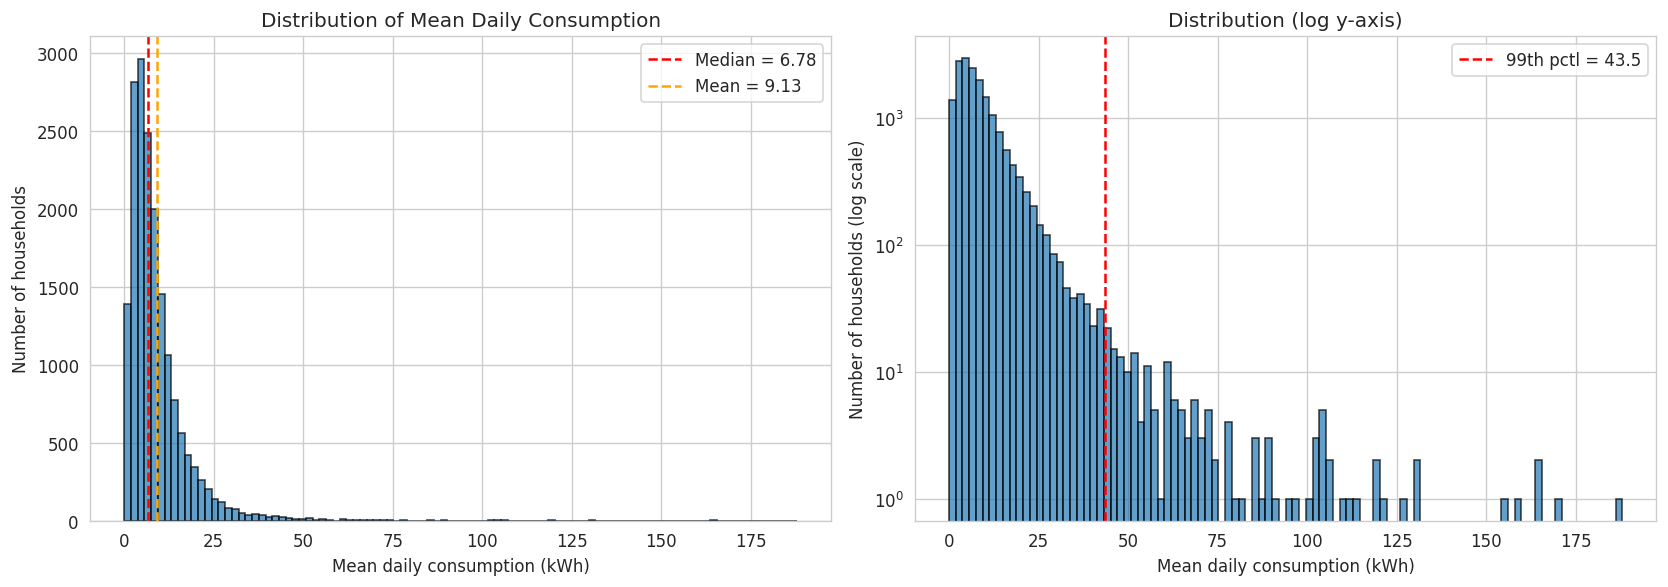

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
axes[0].hist(household_mean, bins=100, edgecolor='black', alpha=0.7)
axes[0].axvline(household_mean.median(), color='red', linestyle='--',
                label=f'Median = {household_mean.median():.2f}')
axes[0].axvline(household_mean.mean(), color='orange', linestyle='--',
                label=f'Mean = {household_mean.mean():.2f}')
axes[0].set_xlabel('Mean daily consumption (kWh)')
axes[0].set_ylabel('Number of households')
axes[0].set_title('Distribution of Mean Daily Consumption')
axes[0].legend()

# Log scale for better tail visibility
axes[1].hist(household_mean, bins=100, edgecolor='black', alpha=0.7)
axes[1].axvline(np.percentile(household_mean, 99), color='red', linestyle='--',
                label=f'99th pctl = {np.percentile(household_mean, 99):.1f}')
axes[1].set_xlabel('Mean daily consumption (kWh)')
axes[1].set_ylabel('Number of households (log scale)')
axes[1].set_title('Distribution (log y-axis)')
axes[1].set_yscale('log')
axes[1].legend()

plt.tight_layout()
plt.show()

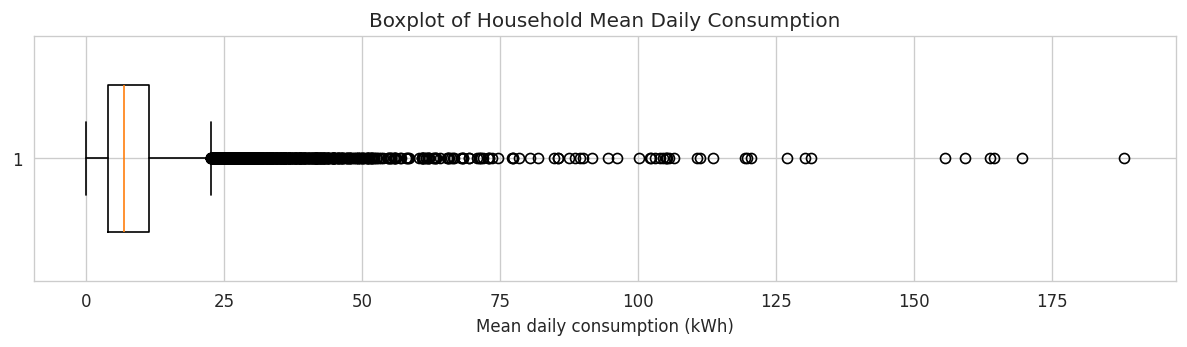

In [8]:
# Boxplot of household mean consumption
fig, ax = plt.subplots(figsize=(10, 3))
ax.boxplot(household_mean, vert=False, widths=0.6)
ax.set_xlabel('Mean daily consumption (kWh)')
ax.set_title('Boxplot of Household Mean Daily Consumption')
plt.tight_layout()
plt.show()

### Outlier Identification

Using the IQR method on household mean consumption to identify outliers.

In [9]:
Q1 = household_mean.quantile(0.25)
Q3 = household_mean.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

n_outliers = int(((household_mean < lower_bound) | (household_mean > upper_bound)).sum())

print(f"Q1 = {Q1:.2f}, Q3 = {Q3:.2f}, IQR = {IQR:.2f}")
print(f"Lower bound = {lower_bound:.2f}, Upper bound = {upper_bound:.2f}")
print(f"Outliers: {n_outliers} households ({n_outliers / len(household_mean) * 100:.1f}%)")
print(f"\n1st percentile: {household_mean.quantile(0.01):.3f} kWh/day")
print(f"99th percentile: {household_mean.quantile(0.99):.3f} kWh/day")

Q1 = 3.87, Q3 = 11.36, IQR = 7.49
Lower bound = -7.36, Upper bound = 22.59
Outliers: 1012 households (5.8%)

1st percentile: 0.002 kWh/day
99th percentile: 43.470 kWh/day


### Temporal Patterns

Aggregate daily consumption profile across all households and monthly averages.

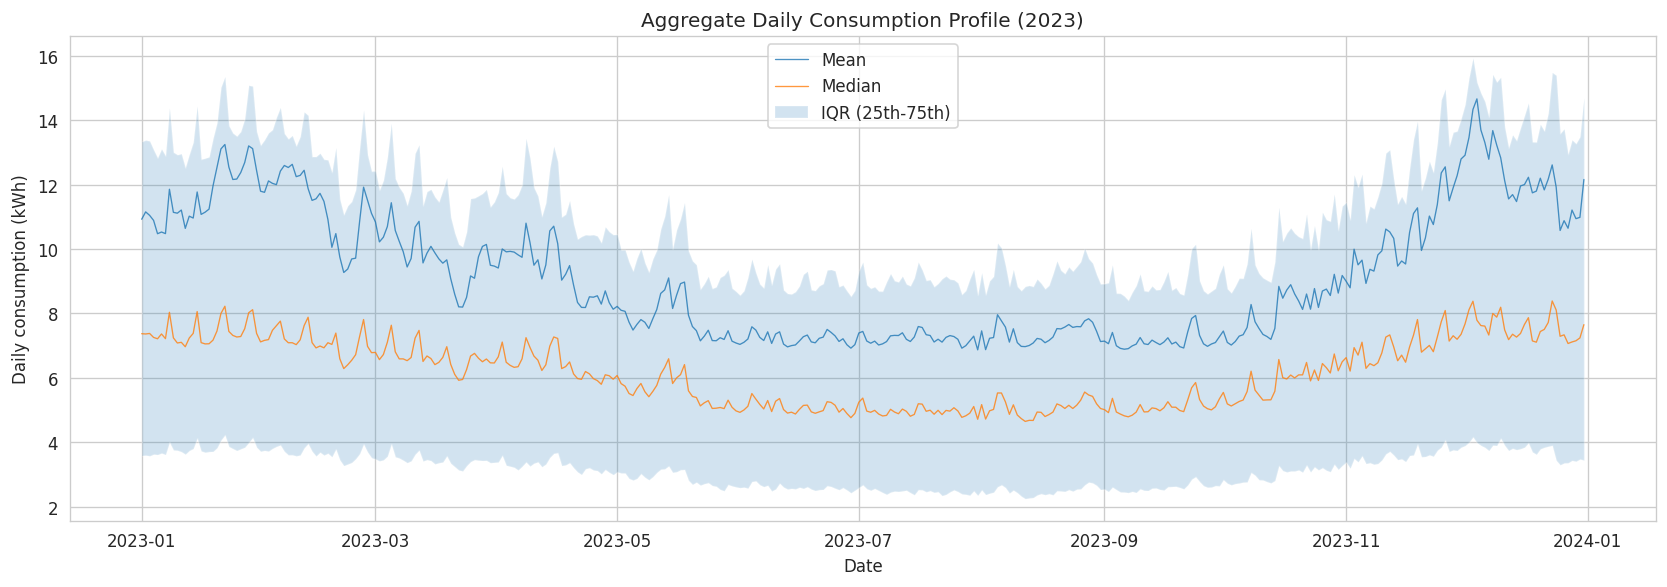

In [10]:
# Aggregate daily consumption profile
daily_avg = ts.mean(axis=0)
daily_median = ts.median(axis=0)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dates, daily_avg, label='Mean', alpha=0.8, linewidth=0.8)
ax.plot(dates, daily_median, label='Median', alpha=0.8, linewidth=0.8)
ax.fill_between(dates,
                ts.quantile(0.25, axis=0),
                ts.quantile(0.75, axis=0),
                alpha=0.2, label='IQR (25th-75th)')
ax.set_xlabel('Date')
ax.set_ylabel('Daily consumption (kWh)')
ax.set_title('Aggregate Daily Consumption Profile (2023)')
ax.legend()
plt.tight_layout()
plt.show()

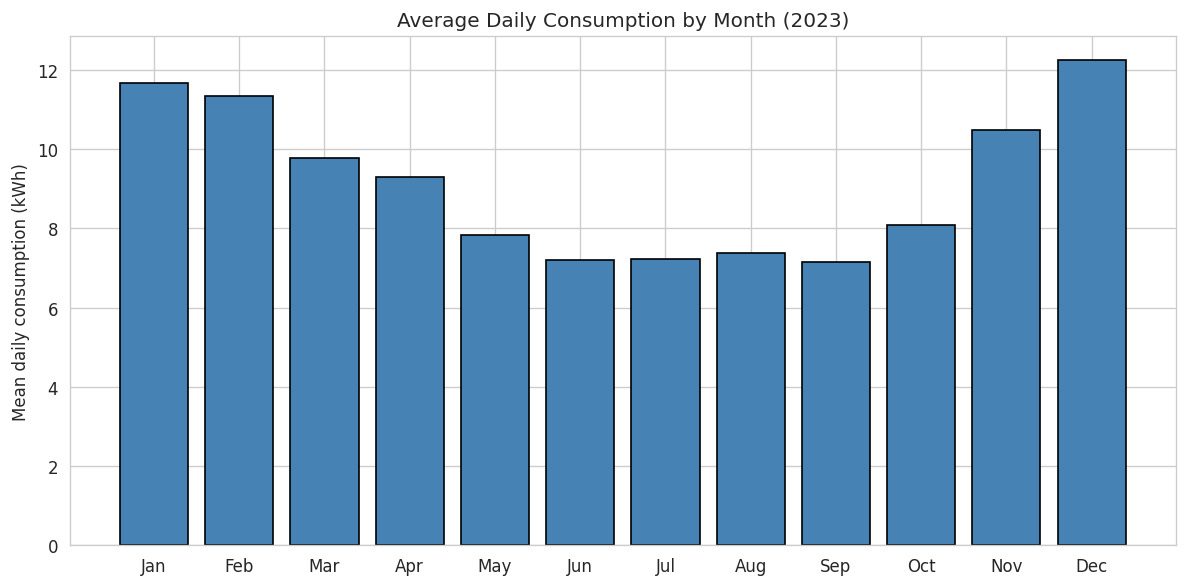

In [11]:
# Monthly average consumption
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

monthly_means = []
for m in range(1, 13):
    cols = [c for c, d in zip(ts.columns, dates) if d.month == m]
    monthly_means.append(ts[cols].mean(axis=1).mean())

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(month_names, monthly_means, color='steelblue', edgecolor='black')
ax.set_ylabel('Mean daily consumption (kWh)')
ax.set_title('Average Daily Consumption by Month (2023)')
plt.tight_layout()
plt.show()

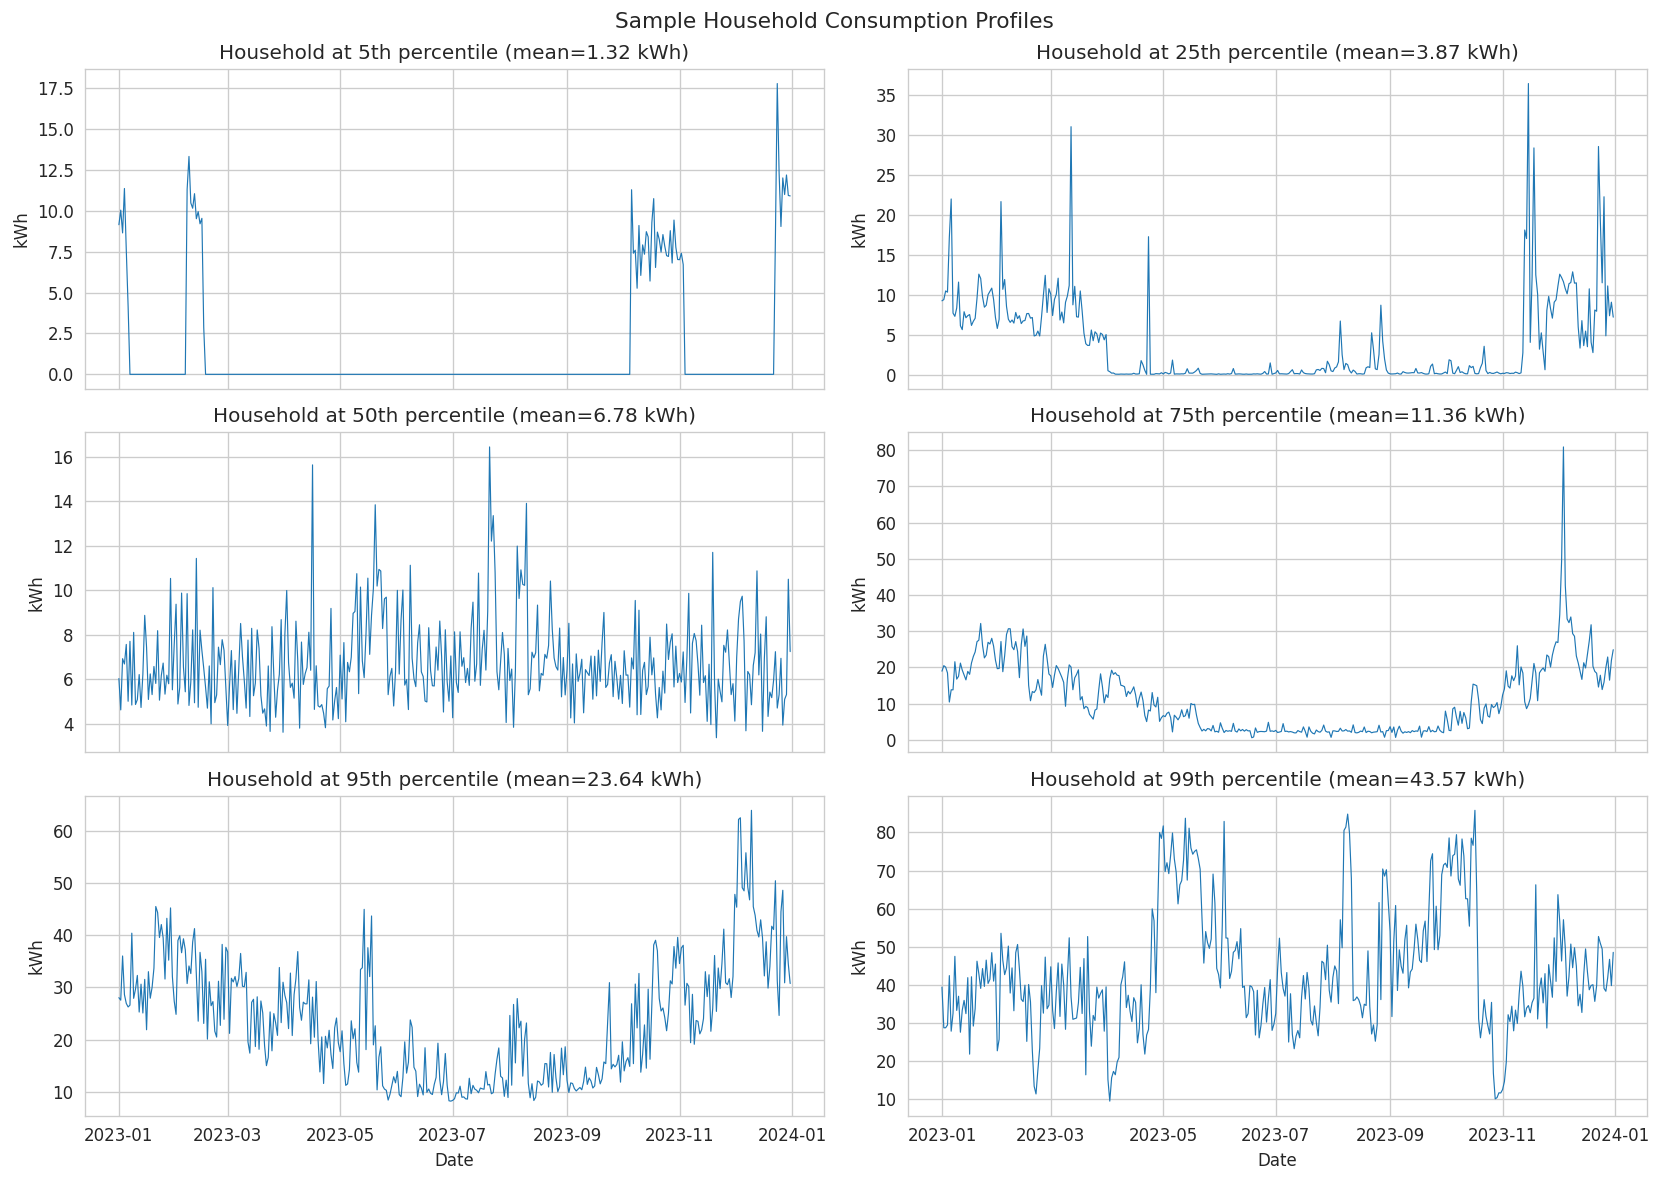

In [12]:
# Sample time series from different quantiles
fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
quantiles = [0.05, 0.25, 0.50, 0.75, 0.95, 0.99]

for i, q in enumerate(quantiles):
    ax = axes[i // 2, i % 2]
    target_val = household_mean.quantile(q)
    idx = (household_mean - target_val).abs().idxmin()
    ax.plot(dates, ts.loc[idx], linewidth=0.7)
    ax.set_title(f'Household at {q*100:.0f}th percentile '
                 f'(mean={household_mean.loc[idx]:.2f} kWh)')
    ax.set_ylabel('kWh')

axes[-1, 0].set_xlabel('Date')
axes[-1, 1].set_xlabel('Date')
plt.suptitle('Sample Household Consumption Profiles', fontsize=13)
plt.tight_layout()
plt.show()

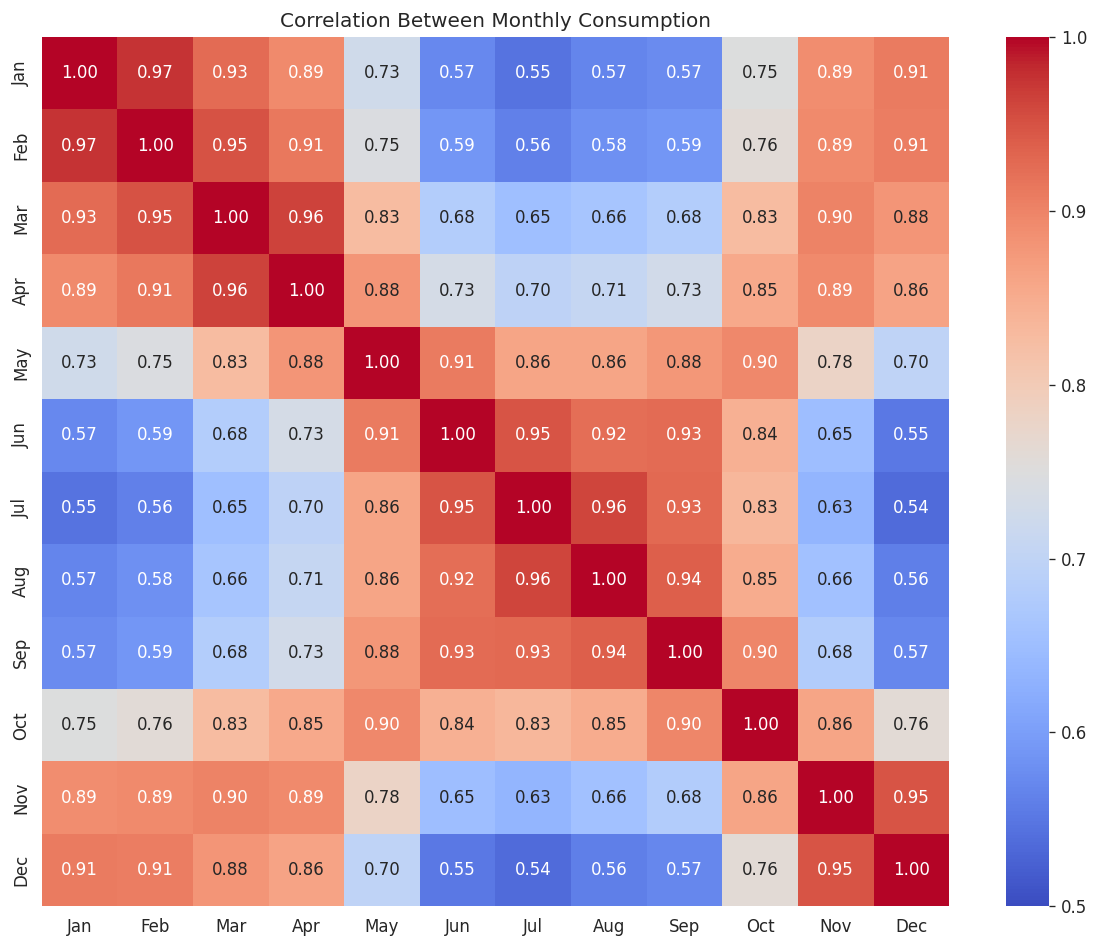

In [13]:
# Monthly correlation heatmap
monthly_data = pd.DataFrame()
for m in range(1, 13):
    cols = [c for c, d in zip(ts.columns, dates) if d.month == m]
    monthly_data[month_names[m - 1]] = ts[cols].mean(axis=1)

fig, ax = plt.subplots(figsize=(10, 8))
corr = monthly_data.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax,
            vmin=0.5, vmax=1.0)
ax.set_title('Correlation Between Monthly Consumption')
plt.tight_layout()
plt.show()

---

## 2. Data Preprocessing

We apply several normalization strategies to the raw time series. The goal is to evaluate which preprocessing best serves clustering:

| Method | Effect |
|---|---|
| **Raw** | Preserves absolute consumption levels |
| **Z-score** (per household) | Centers to mean=0, std=1; removes scale, preserves shape |
| **Min-Max** (per household) | Scales to [0, 1]; removes scale, preserves shape |
| **Log** (log1p) | Reduces right-skew, compresses high values |
| **Log + Z-score** | Combines skew reduction with normalization |

In [14]:
# Z-score normalization (per household)
ts_zscore = ts.sub(household_mean, axis=0).div(household_std.replace(0, 1), axis=0)

# Min-max normalization (per household)
ts_range = (household_max - household_min).replace(0, 1)
ts_minmax = ts.sub(household_min, axis=0).div(ts_range, axis=0)

# Log transformation (log1p to handle zeros)
ts_log = np.log1p(ts)

# Log + Z-score
log_mean = ts_log.mean(axis=1)
log_std = ts_log.std(axis=1)
ts_log_zscore = ts_log.sub(log_mean, axis=0).div(log_std.replace(0, 1), axis=0)

print('Preprocessing complete.')
print(f'  Raw:         shape={ts.shape}')
print(f'  Z-score:     shape={ts_zscore.shape}')
print(f'  Min-Max:     shape={ts_minmax.shape}')
print(f'  Log:         shape={ts_log.shape}')
print(f'  Log+Z-score: shape={ts_log_zscore.shape}')

Preprocessing complete.
  Raw:         shape=(17547, 365)
  Z-score:     shape=(17547, 365)
  Min-Max:     shape=(17547, 365)
  Log:         shape=(17547, 365)
  Log+Z-score: shape=(17547, 365)


### Comparison of Preprocessing Methods

Visualize the same household (near the median) under each preprocessing approach.

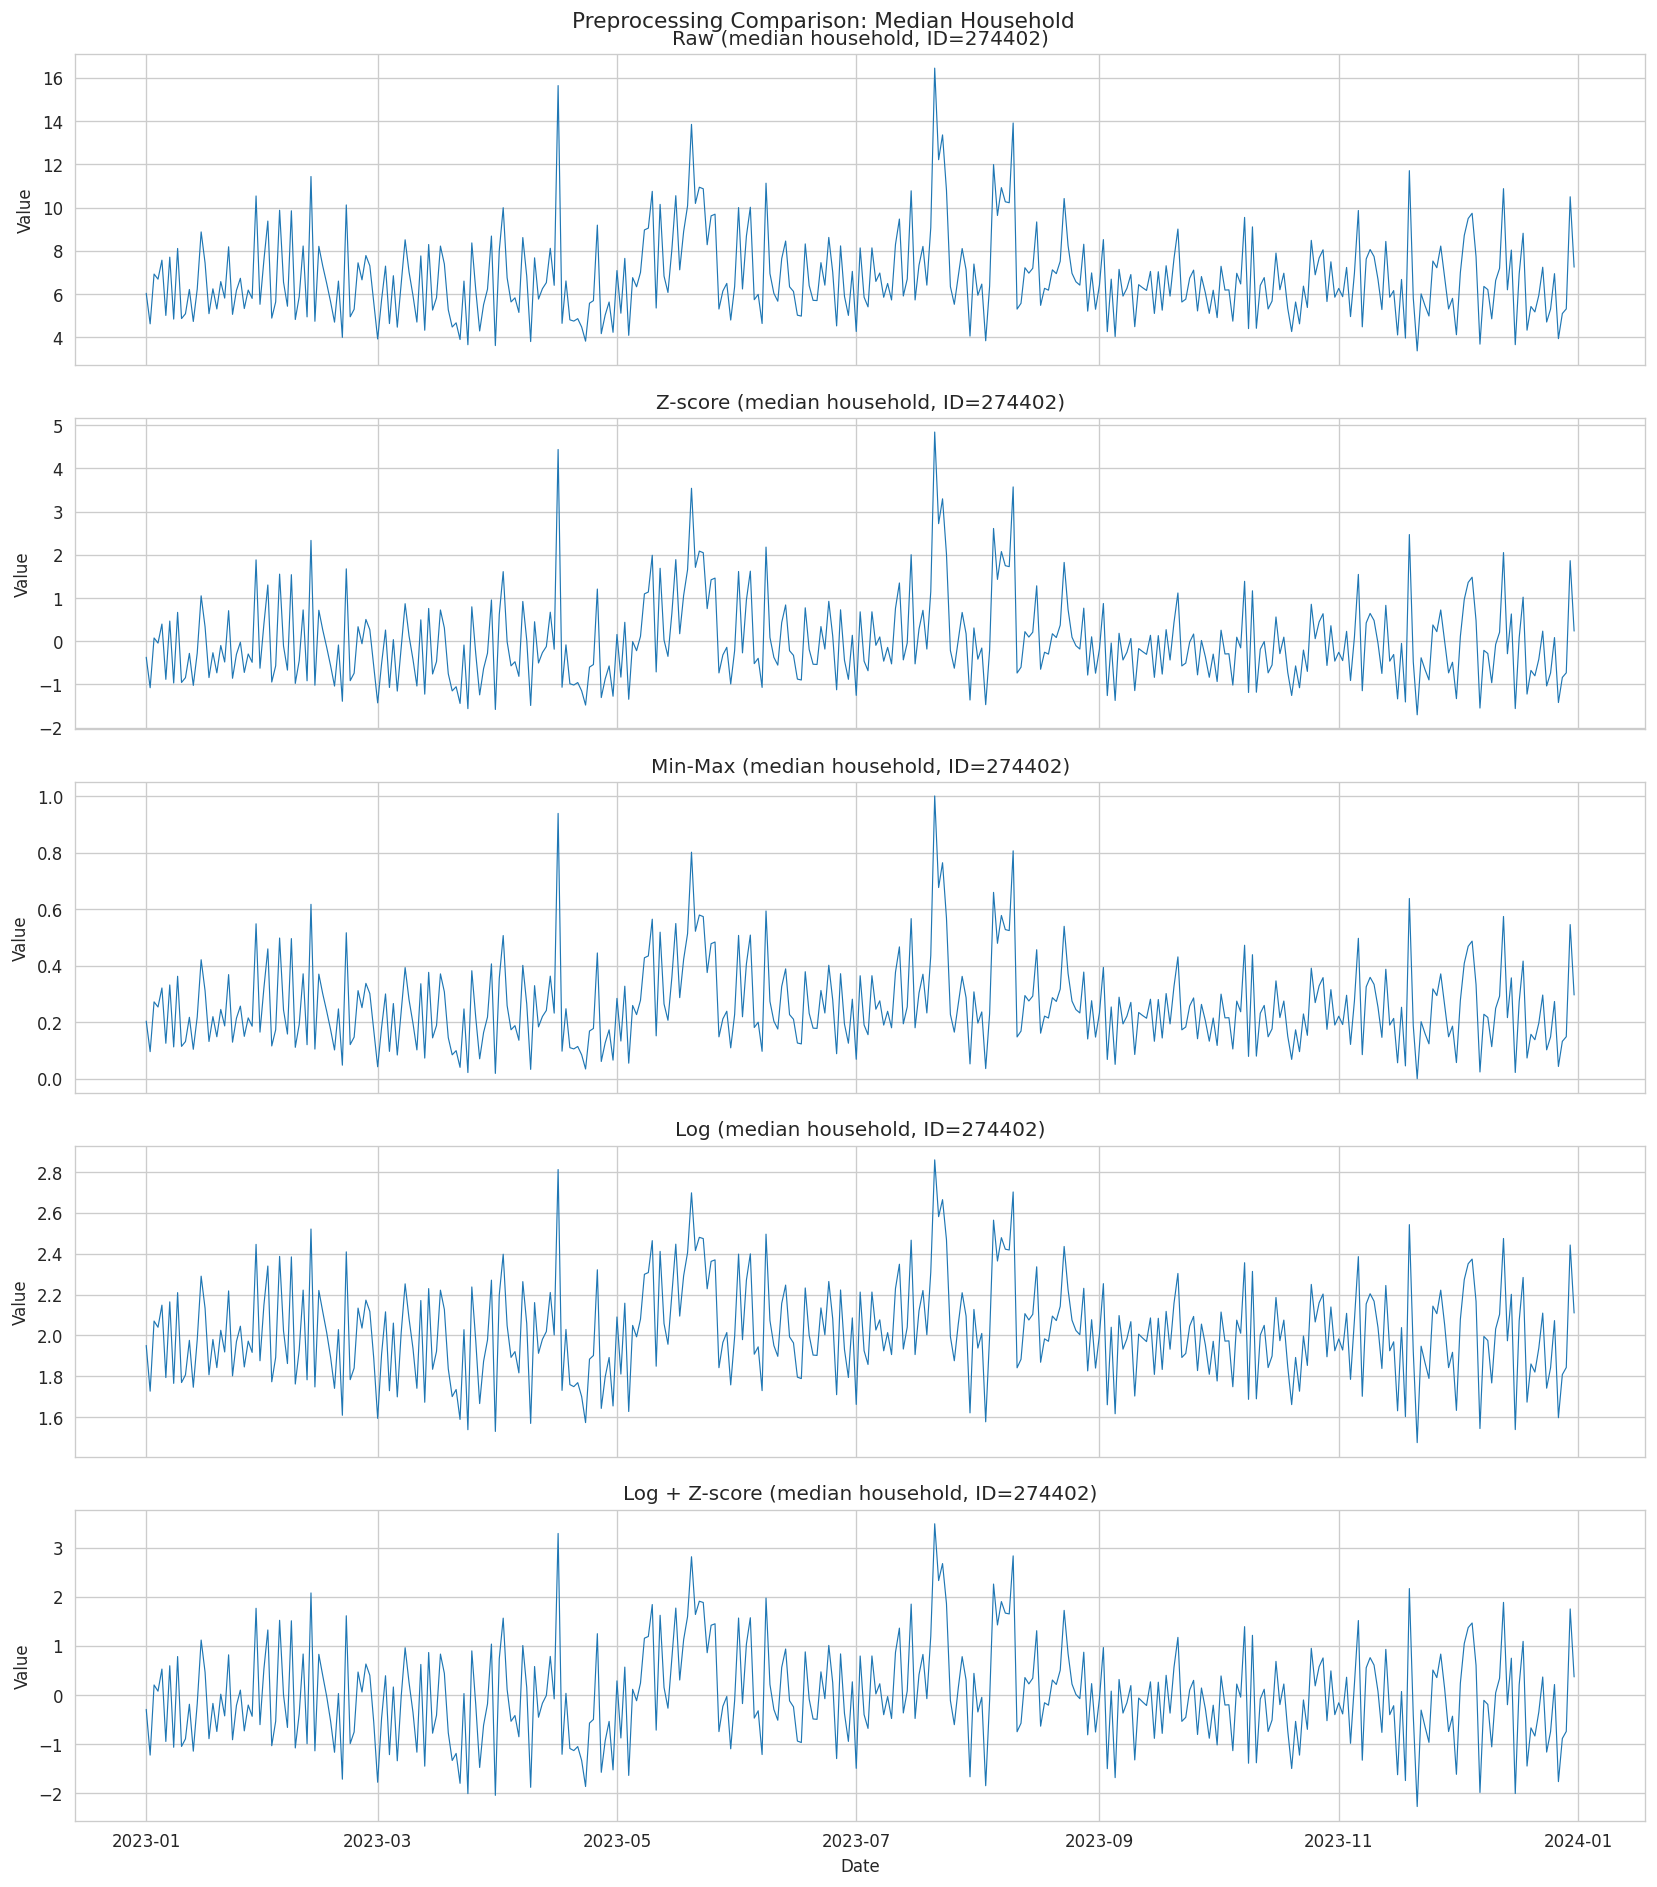

In [15]:
# Pick a representative household near the median
median_idx = (household_mean - household_mean.median()).abs().idxmin()

fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=True)
titles = ['Raw', 'Z-score', 'Min-Max', 'Log', 'Log + Z-score']
datasets = [ts, ts_zscore, ts_minmax, ts_log, ts_log_zscore]

for ax, title, data in zip(axes, titles, datasets):
    ax.plot(dates, data.loc[median_idx], linewidth=0.7)
    ax.set_title(f'{title} (median household, ID={ids.loc[median_idx]})')
    ax.set_ylabel('Value')

axes[-1].set_xlabel('Date')
plt.suptitle('Preprocessing Comparison: Median Household', fontsize=13)
plt.tight_layout()
plt.show()

**Observations:**
- **Z-score** and **Min-Max** remove absolute scale, making households comparable by pattern shape.
- **Log** compresses the high-consumption tail and makes the distribution more symmetric.
- **Log + Z-score** combines both benefits.

For clustering, we will primarily use **extracted features** (next section), which naturally handle scale differences. We also test clustering on z-score and log-transformed time series for comparison.

---

## 3. Feature Extraction

We extract 16 domain-relevant features from each household's daily time series. These features capture consumption level, variability, distribution shape, temporal dynamics, and periodicity.

| Feature | Description |
|---|---|
| `mean` | Average daily consumption (kWh) |
| `std` | Standard deviation of daily consumption |
| `cv` | Coefficient of variation (std / mean) -- relative variability |
| `min`, `max` | Minimum and maximum daily consumption |
| `skewness` | Asymmetry of the daily consumption distribution |
| `kurtosis` | Tailedness of the distribution (excess kurtosis) |
| `trend_slope` | Linear regression slope over the year (positive = increasing trend) |
| `winter_summer_ratio` | Mean winter (Dec-Feb) / mean summer (Jun-Aug) consumption |
| `peak_month` | Month (1-12) with highest average consumption |
| `weekend_weekday_ratio` | Weekend / weekday average consumption |
| `autocorr_lag1` | Autocorrelation at lag 1 day (day-to-day persistence) |
| `autocorr_lag7` | Autocorrelation at lag 7 days (weekly pattern) |
| `entropy` | Information entropy of the consumption histogram (regularity) |
| `zero_days` | Number of days with zero consumption |

In [16]:
features = pd.DataFrame()
features['id'] = ids.values

# --- Basic statistics ---
features['mean'] = household_mean.values
features['std'] = household_std.values
features['cv'] = (household_std / household_mean.replace(0, np.nan)).fillna(0).values
features['min'] = household_min.values
features['max'] = household_max.values
features['skewness'] = ts.skew(axis=1).values
features['kurtosis'] = ts.kurtosis(axis=1).values

# --- Trend: linear regression slope over the year ---
day_numbers = np.arange(ts.shape[1], dtype=np.float64)
day_centered = day_numbers - day_numbers.mean()
denominator = np.sum(day_centered ** 2)
ts_centered = ts.values - ts.values.mean(axis=1, keepdims=True)
features['trend_slope'] = (ts_centered @ day_centered) / denominator

# --- Seasonality: winter/summer ratio ---
winter_cols = [c for c, d in zip(ts.columns, dates) if d.month in [12, 1, 2]]
summer_cols = [c for c, d in zip(ts.columns, dates) if d.month in [6, 7, 8]]
winter_mean = ts[winter_cols].mean(axis=1)
summer_mean = ts[summer_cols].mean(axis=1)
features['winter_summer_ratio'] = (winter_mean / summer_mean.replace(0, np.nan)).fillna(1).values

# --- Peak month ---
features['peak_month'] = monthly_data.idxmax(axis=1).map(
    {m: i + 1 for i, m in enumerate(month_names)}
).values

# --- Weekend/weekday ratio ---
day_of_week = dates.dayofweek  # Monday=0, Sunday=6
weekend_cols = [c for c, dow in zip(ts.columns, day_of_week) if dow >= 5]
weekday_cols = [c for c, dow in zip(ts.columns, day_of_week) if dow < 5]
weekend_mean = ts[weekend_cols].mean(axis=1)
weekday_mean = ts[weekday_cols].mean(axis=1)
features['weekend_weekday_ratio'] = (
    weekend_mean / weekday_mean.replace(0, np.nan)
).fillna(1).values

# --- Autocorrelation at lag 1 and lag 7 ---
def compute_autocorr(data, lag):
    """Compute autocorrelation at a given lag for each row."""
    n = data.shape[1]
    mean = data.mean(axis=1, keepdims=True)
    centered = data - mean
    var = np.sum(centered ** 2, axis=1)
    cov = np.sum(centered[:, :n - lag] * centered[:, lag:], axis=1)
    return np.where(var > 0, cov / var, 0)

ts_arr = ts.values
features['autocorr_lag1'] = compute_autocorr(ts_arr, 1)
features['autocorr_lag7'] = compute_autocorr(ts_arr, 7)

# --- Entropy (approximate, based on histogram of daily values) ---
def row_entropy(row, bins=20):
    counts, _ = np.histogram(row, bins=bins)
    probs = counts / counts.sum()
    probs = probs[probs > 0]
    return -np.sum(probs * np.log2(probs))

features['entropy'] = np.apply_along_axis(row_entropy, 1, ts_arr)

# --- Zero-day count ---
features['zero_days'] = (ts == 0).sum(axis=1).values

print(f'Extracted {features.shape[1] - 1} features for {features.shape[0]} households')
features.drop(columns=['id']).describe().round(3)

Extracted 15 features for 17547 households


,mean,std,cv,min,max,skewness,kurtosis,trend_slope,winter_summer_ratio,peak_month,weekend_weekday_ratio,autocorr_lag1,autocorr_lag7,entropy,zero_days
count,17547.000,17547.000,17547.000,17547.000,17547.000,17547.000,17547.000,17547.000,17547.000,17547.000,17547.000,17547.000,17547.000,17547.000,17547.000
mean,9.131,4.512,0.551,2.625,27.153,1.151,4.477,-0.003,146.780,6.924,1.091,0.457,0.353,3.344,9.607
std,9.405,5.737,0.772,3.662,31.580,1.484,19.303,0.018,11512.641,4.517,2.918,0.289,0.250,0.688,49.609
min,0.000,0.000,0.000,0.000,0.000,-9.059,-1.993,-0.330,0.000,1.000,0.000,-0.819,-0.398,-0.000,0.000
25%,3.869,1.571,0.307,0.806,10.610,0.462,0.020,-0.004,1.030,2.000,0.987,0.234,0.153,3.192,0.000
50%,6.776,2.619,0.407,1.737,17.981,0.846,0.915,-0.000,1.245,7.000,1.045,0.431,0.300,3.546,0.000
75%,11.356,4.901,0.583,3.338,32.020,1.391,2.925,0.002,1.672,12.000,1.132,0.694,0.539,3.756,0.000
max,188.015,91.983,19.105,88.363,1051.740,19.105,365.000,0.314,1430081.733,12.000,385.265,0.992,0.968,4.223,365.000


### Feature Distributions

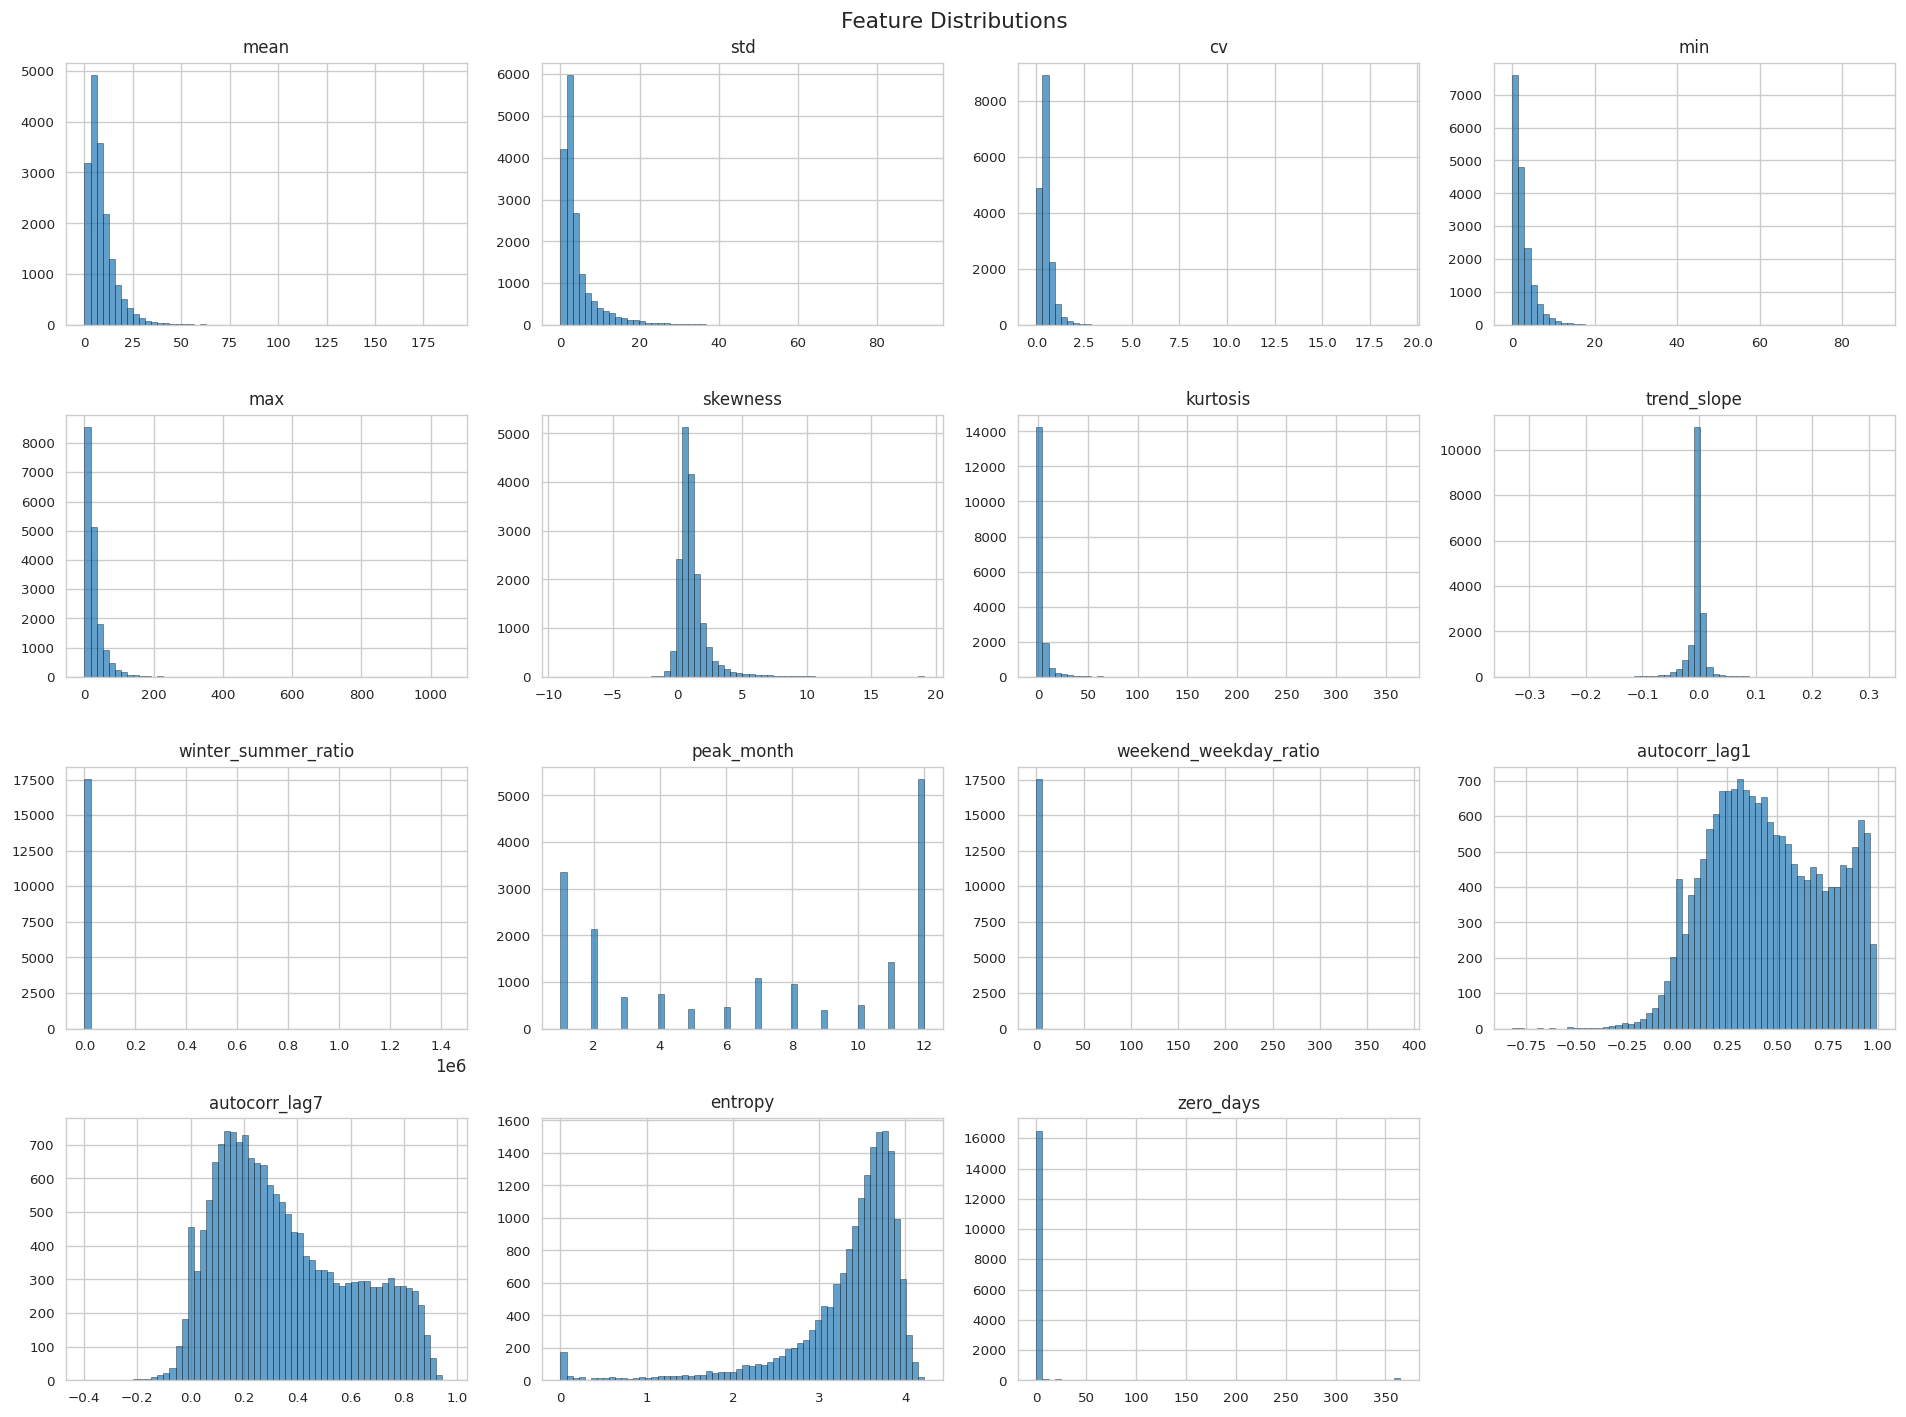

In [17]:
feat_cols = [c for c in features.columns if c != 'id']
n_feats = len(feat_cols)
ncols = 4
nrows = (n_feats + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3 * nrows))
axes_flat = axes.flatten()

for i, col in enumerate(feat_cols):
    axes_flat[i].hist(features[col], bins=60, edgecolor='black', alpha=0.7,
                      linewidth=0.3)
    axes_flat[i].set_title(col, fontsize=10)
    axes_flat[i].tick_params(labelsize=8)

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('Feature Distributions', fontsize=13)
plt.tight_layout()
plt.show()

### Feature Correlation Matrix

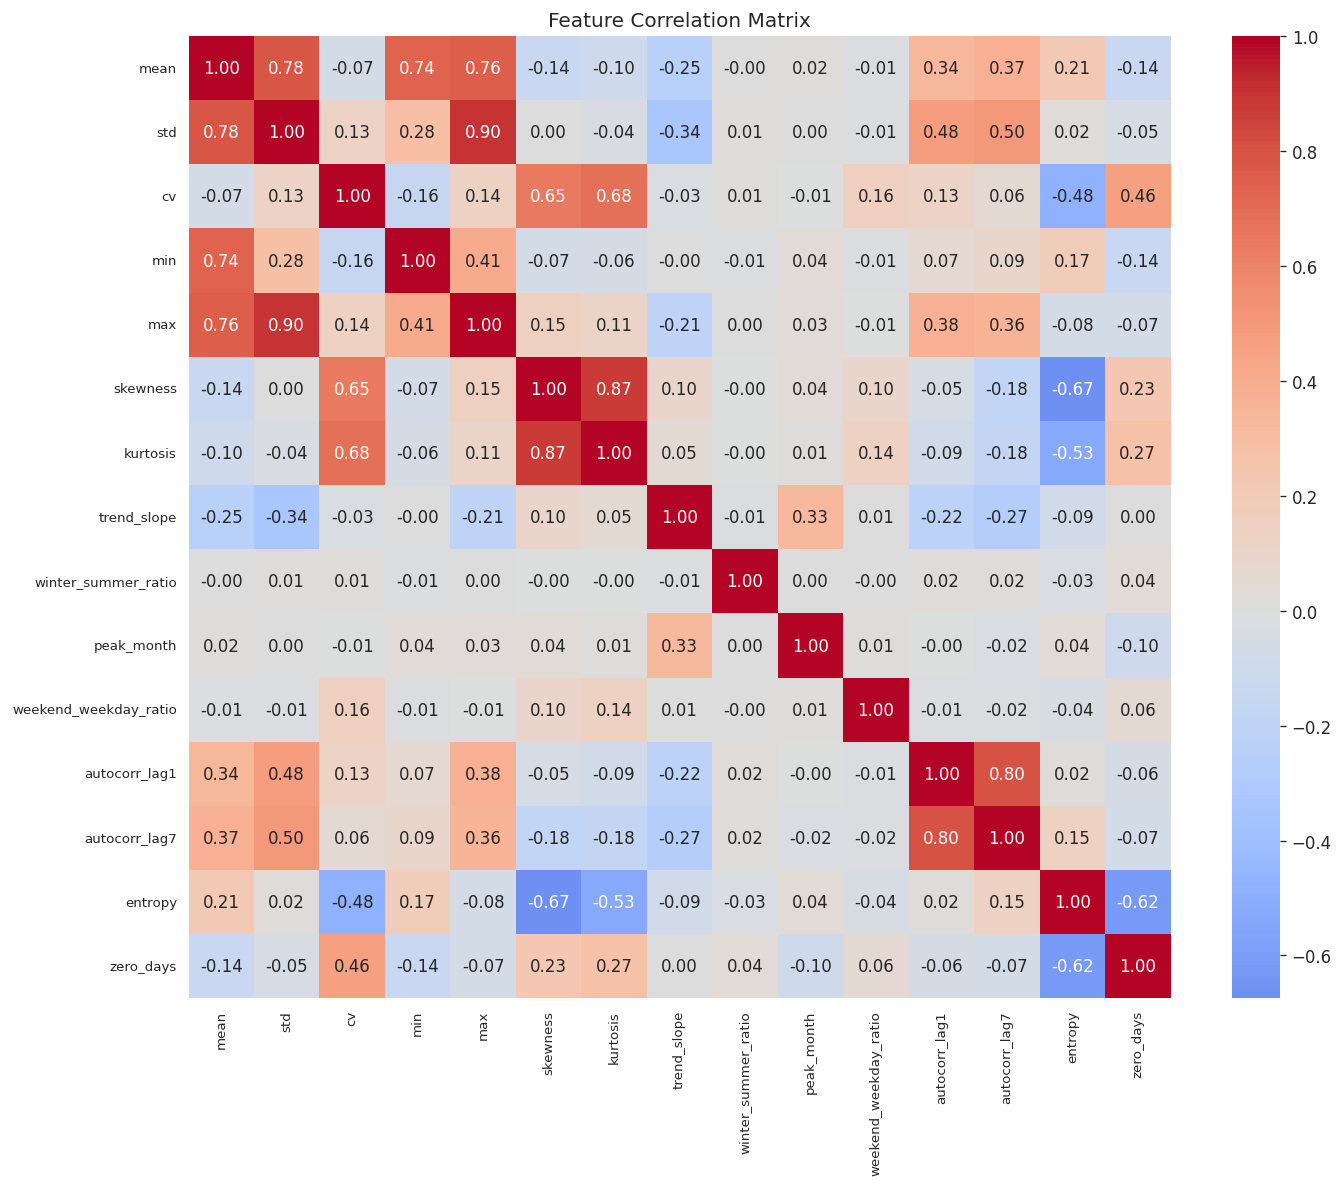

In [18]:
fig, ax = plt.subplots(figsize=(12, 10))
corr = features[feat_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, center=0,
            xticklabels=True, yticklabels=True)
ax.set_title('Feature Correlation Matrix')
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

### Standardize Features for Clustering

Before clustering, all features are standardized to zero mean and unit variance. Extreme values in ratio features are capped at the 99th percentile to prevent distortion.

In [19]:
feature_cols = [c for c in features.columns if c != 'id']
X_features_raw = features[feature_cols].values.copy()

# Handle inf/nan
X_features_raw = np.nan_to_num(X_features_raw, nan=0.0, posinf=0.0, neginf=0.0)

# Cap extreme values in ratio features
for col_idx, col_name in enumerate(feature_cols):
    if col_name in ['winter_summer_ratio', 'weekend_weekday_ratio']:
        p99 = np.percentile(X_features_raw[:, col_idx], 99)
        X_features_raw[:, col_idx] = np.clip(X_features_raw[:, col_idx], 0, p99)

# Standardize
scaler = StandardScaler()
X_features = scaler.fit_transform(X_features_raw)

print(f'Feature matrix for clustering: {X_features.shape}')

Feature matrix for clustering: (17547, 15)


### Dimensionality Reduction (PCA)

PCA reveals how many independent dimensions the feature space effectively has.

Features PCA: 9 components for 90% variance
  First 5 components: [0.257 0.22  0.117 0.084 0.067]
Z-score TS PCA: 10 components explain 33.1% variance


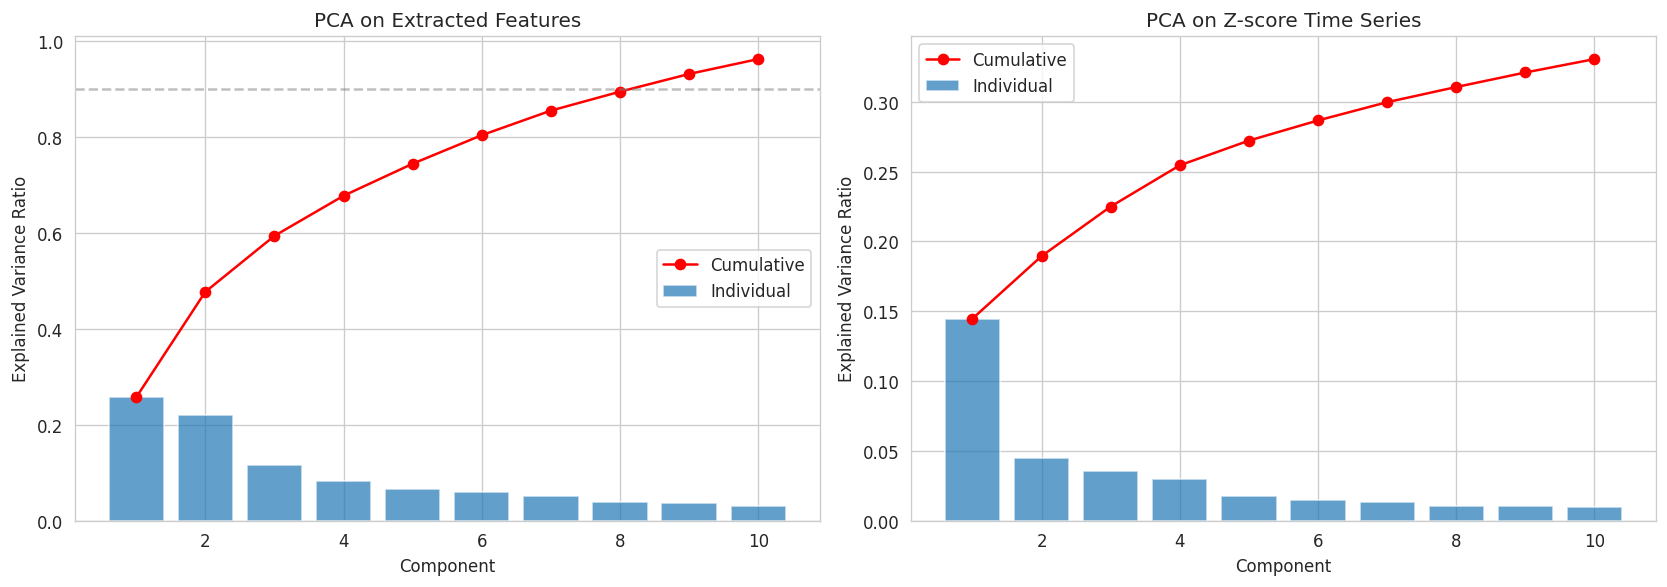

In [20]:
# PCA on extracted features
pca = PCA(n_components=min(10, X_features.shape[1]))
X_pca = pca.fit_transform(X_features)
explained_var = pca.explained_variance_ratio_
cumvar = np.cumsum(explained_var)
n_components_90 = int(np.argmax(cumvar >= 0.90)) + 1

# PCA on z-score time series
pca_ts = PCA(n_components=10)
X_ts_pca = pca_ts.fit_transform(ts_zscore.values)
ts_cumvar = np.cumsum(pca_ts.explained_variance_ratio_)

print(f'Features PCA: {n_components_90} components for 90% variance')
print(f'  First 5 components: {explained_var[:5].round(3)}')
print(f'Z-score TS PCA: 10 components explain {ts_cumvar[-1]*100:.1f}% variance')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(explained_var) + 1), explained_var, alpha=0.7,
            label='Individual')
axes[0].plot(range(1, len(explained_var) + 1), cumvar, 'ro-',
             label='Cumulative')
axes[0].axhline(y=0.90, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('PCA on Extracted Features')
axes[0].legend()

axes[1].bar(range(1, 11), pca_ts.explained_variance_ratio_, alpha=0.7,
            label='Individual')
axes[1].plot(range(1, 11), ts_cumvar, 'ro-', label='Cumulative')
axes[1].set_xlabel('Component')
axes[1].set_ylabel('Explained Variance Ratio')
axes[1].set_title('PCA on Z-score Time Series')
axes[1].legend()

plt.tight_layout()
plt.show()

---

## 4. Clustering

We evaluate three clustering algorithms:
1. **K-Means++** on extracted features (primary)
2. **K-Means++** on z-score time series (PCA-reduced) and log-transformed time series (PCA-reduced)
3. **Hierarchical clustering** (Ward linkage) on features
4. **DBSCAN** on PCA-reduced features

### 4.1 K-Means++ on Extracted Features (k=2..15)

In [21]:
inertias_feat = []
silhouettes_feat = []
ch_scores_feat = []
db_scores_feat = []

print('K-Means++ on extracted features (standardized):')
print(f'{"k":>4} {"Inertia":>12} {"Silhouette":>11} {"CH":>8} {"DB":>8}')
print('-' * 50)

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300,
                random_state=RANDOM_STATE)
    labels = km.fit_predict(X_features)
    inertias_feat.append(km.inertia_)

    sil = silhouette_score(X_features, labels,
                           sample_size=min(5000, len(labels)),
                           random_state=RANDOM_STATE)
    silhouettes_feat.append(sil)
    ch_scores_feat.append(calinski_harabasz_score(X_features, labels))
    db_scores_feat.append(davies_bouldin_score(X_features, labels))

    print(f'{k:4d} {km.inertia_:12.0f} {sil:11.4f} '
          f'{ch_scores_feat[-1]:8.0f} {db_scores_feat[-1]:8.3f}')

K-Means++ on extracted features (standardized):
   k      Inertia  Silhouette       CH       DB
--------------------------------------------------


   2       221371      0.3672     3316    1.645


   3       189399      0.3912     3418    1.462


   4       172115      0.3885     3095    1.349


   5       156622      0.2420     2984    1.480


...

  11       105795      0.1819     2609    1.307


  12       101547      0.1820     2538    1.298


  13        97423      0.1882     2486    1.288


  14        94092      0.1837     2424    1.302


  15        90224      0.1842     2401    1.287


### 4.2 K-Means++ on Time Series (PCA-reduced)

In [22]:
# K-Means on z-score time series (PCA-10)
inertias_ts = []
silhouettes_ts = []
ch_scores_ts = []
db_scores_ts = []

print('K-Means++ on z-score time series (PCA-10):')
print(f'{"k":>4} {"Inertia":>12} {"Silhouette":>11} {"CH":>8} {"DB":>8}')
print('-' * 50)

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300,
                random_state=RANDOM_STATE)
    labels = km.fit_predict(X_ts_pca)
    inertias_ts.append(km.inertia_)

    sil = silhouette_score(X_ts_pca, labels,
                           sample_size=min(5000, len(labels)),
                           random_state=RANDOM_STATE)
    silhouettes_ts.append(sil)
    ch_scores_ts.append(calinski_harabasz_score(X_ts_pca, labels))
    db_scores_ts.append(davies_bouldin_score(X_ts_pca, labels))

    print(f'{k:4d} {km.inertia_:12.0f} {sil:11.4f} '
          f'{ch_scores_ts[-1]:8.0f} {db_scores_ts[-1]:8.3f}')

K-Means++ on z-score time series (PCA-10):
   k      Inertia  Silhouette       CH       DB
--------------------------------------------------


   2      1401363      0.2299     6540    1.508


   3      1206497      0.2078     5215    1.636


   4      1101698      0.1748     4363    1.839


   5      1031629      0.1631     3792    1.772


...

  11       820786      0.1376     2356    1.828


  12       800923      0.1353     2235    1.835


  13       782418      0.1310     2131    1.793


  14       766807      0.1312     2035    1.792


  15       751932      0.1240     1952    1.802


In [23]:
# K-Means on log-transformed time series (PCA-10)
log_scaler = StandardScaler()
X_log_scaled = log_scaler.fit_transform(ts_log.values)
pca_log = PCA(n_components=10)
X_log_pca = pca_log.fit_transform(X_log_scaled)

inertias_log = []
silhouettes_log = []

print('K-Means++ on log-transformed time series (PCA-10):')
print(f'{"k":>4} {"Inertia":>12} {"Silhouette":>11}')
print('-' * 30)

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300,
                random_state=RANDOM_STATE)
    labels = km.fit_predict(X_log_pca)
    inertias_log.append(km.inertia_)

    sil = silhouette_score(X_log_pca, labels,
                           sample_size=min(5000, len(labels)),
                           random_state=RANDOM_STATE)
    silhouettes_log.append(sil)

    print(f'{k:4d} {km.inertia_:12.0f} {sil:11.4f}')

K-Means++ on log-transformed time series (PCA-10):
   k      Inertia  Silhouette
------------------------------


   2      2828094      0.4230


   3      2020211      0.3543


   4      1637535      0.3272


   5      1348438      0.3536


...

  11       792815      0.2537


  12       760244      0.2385


  13       731366      0.2351


  14       706812      0.2377


  15       681749      0.2415


### Elbow and Silhouette Comparison

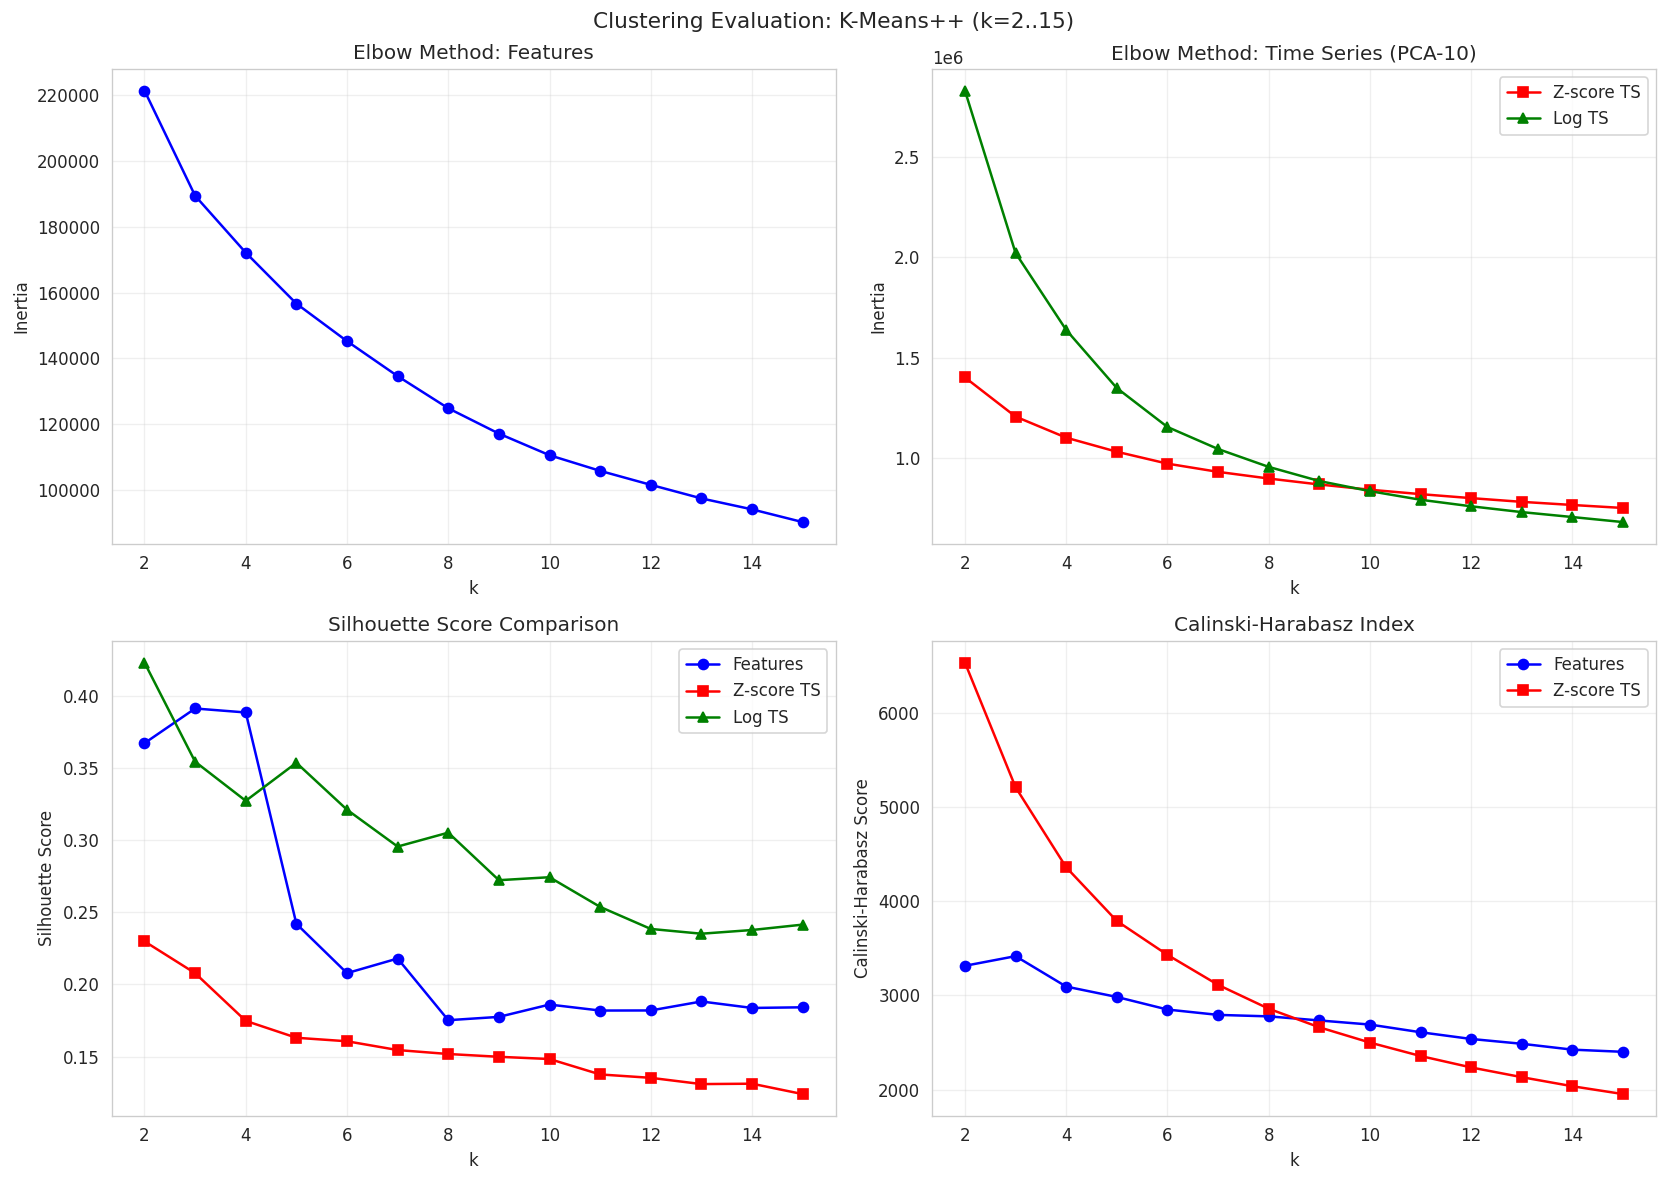

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Elbow: Features
axes[0, 0].plot(list(K_RANGE), inertias_feat, 'bo-', label='Features')
axes[0, 0].set_xlabel('k')
axes[0, 0].set_ylabel('Inertia')
axes[0, 0].set_title('Elbow Method: Features')
axes[0, 0].grid(True, alpha=0.3)

# Elbow: Time Series
axes[0, 1].plot(list(K_RANGE), inertias_ts, 'rs-', label='Z-score TS')
axes[0, 1].plot(list(K_RANGE), inertias_log, 'g^-', label='Log TS')
axes[0, 1].set_xlabel('k')
axes[0, 1].set_ylabel('Inertia')
axes[0, 1].set_title('Elbow Method: Time Series (PCA-10)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Silhouette comparison
axes[1, 0].plot(list(K_RANGE), silhouettes_feat, 'bo-', label='Features')
axes[1, 0].plot(list(K_RANGE), silhouettes_ts, 'rs-', label='Z-score TS')
axes[1, 0].plot(list(K_RANGE), silhouettes_log, 'g^-', label='Log TS')
axes[1, 0].set_xlabel('k')
axes[1, 0].set_ylabel('Silhouette Score')
axes[1, 0].set_title('Silhouette Score Comparison')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Calinski-Harabasz
axes[1, 1].plot(list(K_RANGE), ch_scores_feat, 'bo-', label='Features')
axes[1, 1].plot(list(K_RANGE), ch_scores_ts, 'rs-', label='Z-score TS')
axes[1, 1].set_xlabel('k')
axes[1, 1].set_ylabel('Calinski-Harabasz Score')
axes[1, 1].set_title('Calinski-Harabasz Index')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Clustering Evaluation: K-Means++ (k=2..15)', fontsize=13)
plt.tight_layout()
plt.show()

In [25]:
# Determine optimal k
best_k_feat = list(K_RANGE)[np.argmax(silhouettes_feat)]
best_k_ts = list(K_RANGE)[np.argmax(silhouettes_ts)]

print(f'Best k for features (by silhouette): {best_k_feat} '
      f'(silhouette = {max(silhouettes_feat):.4f})')
print(f'Best k for z-score TS (by silhouette): {best_k_ts} '
      f'(silhouette = {max(silhouettes_ts):.4f})')

Best k for features (by silhouette): 3 (silhouette = 0.3912)
Best k for z-score TS (by silhouette): 2 (silhouette = 0.2299)


### 4.3 Final K-Means Clustering (optimal k on features)

In [26]:
# Final K-Means with increased n_init for stability
km_final = KMeans(n_clusters=best_k_feat, init='k-means++', n_init=20,
                  max_iter=500, random_state=RANDOM_STATE)
labels_feat = km_final.fit_predict(X_features)
features['cluster_kmeans'] = labels_feat

# Cluster sizes
cluster_sizes = pd.Series(labels_feat).value_counts().sort_index()
print(f'K-Means++ with k={best_k_feat} on extracted features\n')
print('Cluster sizes:')
for c, n in cluster_sizes.items():
    print(f'  Cluster {c}: {n:,} households ({n / len(labels_feat) * 100:.1f}%)')

K-Means++ with k=3 on extracted features

Cluster sizes:
  Cluster 0: 517 households (2.9%)
  Cluster 1: 13,959 households (79.6%)
  Cluster 2: 3,071 households (17.5%)


In [27]:
# Cluster profiles (mean feature values)
cluster_profiles = features.groupby('cluster_kmeans')[feature_cols].mean()
cluster_profiles.round(3)

,mean,std,cv,min,max,skewness,kurtosis,trend_slope,winter_summer_ratio,peak_month,weekend_weekday_ratio,autocorr_lag1,autocorr_lag7,entropy,zero_days
cluster_kmeans,,,,,,,,,,,,,,,
0,1.187,1.833,2.598,0.340,21.540,5.467,64.435,0.000,558.880,5.021,1.943,0.281,0.113,0.632,221.646
1,6.874,2.653,0.429,2.343,18.337,1.022,2.921,0.000,1.349,7.091,1.075,0.383,0.287,3.437,2.339
2,20.728,13.412,0.759,4.288,68.173,1.010,1.455,-0.016,738.449,6.485,1.019,0.823,0.696,3.377,6.946


### 4.4 Hierarchical Clustering (Ward Linkage)

In [28]:
hc = AgglomerativeClustering(n_clusters=best_k_feat, linkage='ward')
labels_hc = hc.fit_predict(X_features)
features['cluster_hierarchical'] = labels_hc

sil_hc = silhouette_score(X_features, labels_hc,
                          sample_size=min(5000, len(labels_hc)),
                          random_state=RANDOM_STATE)
ch_hc = calinski_harabasz_score(X_features, labels_hc)
db_hc = davies_bouldin_score(X_features, labels_hc)

print(f'Hierarchical Clustering (Ward, k={best_k_feat}):')
print(f'  Silhouette:        {sil_hc:.4f}')
print(f'  Calinski-Harabasz: {ch_hc:.0f}')
print(f'  Davies-Bouldin:    {db_hc:.3f}')

hc_sizes = pd.Series(labels_hc).value_counts().sort_index()
print('\nCluster sizes:')
for c, n in hc_sizes.items():
    print(f'  Cluster {c}: {n:,} households ({n / len(labels_hc) * 100:.1f}%)')

Hierarchical Clustering (Ward, k=3):
  Silhouette:        0.3721
  Calinski-Harabasz: 3058
  Davies-Bouldin:    1.540

Cluster sizes:
  Cluster 0: 781 households (4.5%)
  Cluster 1: 2,983 households (17.0%)
  Cluster 2: 13,783 households (78.5%)


### 4.5 DBSCAN

DBSCAN is a density-based algorithm that does not require specifying k. We first use the k-distance graph to select an appropriate `eps` value, then try multiple values.

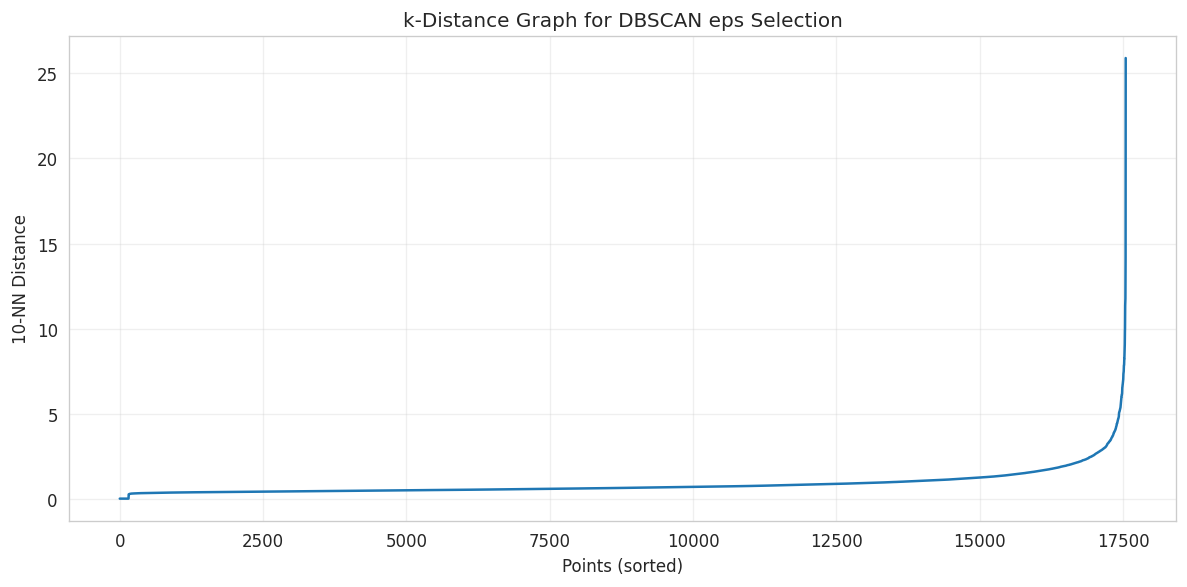

In [29]:
# Use PCA-reduced features for DBSCAN (works better in lower dimensions)
X_feat_pca = PCA(n_components=n_components_90).fit_transform(X_features)

# k-distance graph for eps selection
nn = NearestNeighbors(n_neighbors=10)
nn.fit(X_feat_pca)
distances, _ = nn.kneighbors(X_feat_pca)
k_dist = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_dist)
ax.set_xlabel('Points (sorted)')
ax.set_ylabel('10-NN Distance')
ax.set_title('k-Distance Graph for DBSCAN eps Selection')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
# Try DBSCAN with several eps values
best_dbscan_sil = -1
best_dbscan_eps = None
best_dbscan_labels = None

print(f'{"eps":>5} {"Clusters":>9} {"Noise":>8} {"Noise%":>8} {"Silhouette":>11}')
print('-' * 48)

for eps in [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]:
    db = DBSCAN(eps=eps, min_samples=10)
    labels_db = db.fit_predict(X_feat_pca)
    n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
    n_noise = (labels_db == -1).sum()

    if n_clusters >= 2:
        mask = labels_db != -1
        sil_db = silhouette_score(X_feat_pca[mask], labels_db[mask],
                                  sample_size=min(5000, mask.sum()),
                                  random_state=RANDOM_STATE)
    else:
        sil_db = -1

    print(f'{eps:5.1f} {n_clusters:9d} {n_noise:8d} '
          f'{n_noise / len(labels_db) * 100:7.1f}% {sil_db:11.4f}')

    if sil_db > best_dbscan_sil and n_clusters >= 2:
        best_dbscan_sil = sil_db
        best_dbscan_eps = eps
        best_dbscan_labels = labels_db.copy()

if best_dbscan_labels is not None:
    features['cluster_dbscan'] = best_dbscan_labels
    print(f'\nBest DBSCAN: eps={best_dbscan_eps}, silhouette={best_dbscan_sil:.4f}')
    dbscan_sizes = pd.Series(best_dbscan_labels).value_counts().sort_index()
    for c, n in dbscan_sizes.items():
        label = 'NOISE' if c == -1 else f'Cluster {c}'
        print(f'  {label}: {n:,} households ({n / len(best_dbscan_labels) * 100:.1f}%)')
else:
    print('\nDBSCAN did not find a valid clustering.')

  eps  Clusters    Noise   Noise%  Silhouette
------------------------------------------------


  1.0         4     2717    15.5%      0.4608


  1.5         4     1197     6.8%      0.6010


  2.0         2      606     3.5%      0.6294


  2.5         2      339     1.9%      0.6088


  3.0         2      222     1.3%      0.6068


  3.5         2      167     1.0%      0.7274


  4.0         2      104     0.6%      0.8219

Best DBSCAN: eps=4.0, silhouette=0.8219
  NOISE: 104 households (0.6%)
  Cluster 0: 17,433 households (99.4%)
  Cluster 1: 10 households (0.1%)


**DBSCAN observation:** DBSCAN tends to produce degenerate results on this dataset -- it places the vast majority of data into one cluster and identifies only a handful of outlier points as a second cluster. This is because the feature space is continuous and unimodal (most households are "typical"), making density-based methods unable to find meaningful natural boundaries.

### 4.6 K-Means on Z-score Time Series (for comparison)

In [31]:
km_ts = KMeans(n_clusters=best_k_ts, init='k-means++', n_init=20,
               max_iter=500, random_state=RANDOM_STATE)
labels_ts = km_ts.fit_predict(X_ts_pca)
features['cluster_ts_kmeans'] = labels_ts

sil_ts = silhouette_score(X_ts_pca, labels_ts,
                          sample_size=min(5000, len(labels_ts)),
                          random_state=RANDOM_STATE)
ch_ts = calinski_harabasz_score(X_ts_pca, labels_ts)
db_ts = davies_bouldin_score(X_ts_pca, labels_ts)

ts_sizes = pd.Series(labels_ts).value_counts().sort_index()
print(f'K-Means on z-score time series (k={best_k_ts}):')
print(f'  Silhouette:        {sil_ts:.4f}')
print(f'  Calinski-Harabasz: {ch_ts:.0f}')
print(f'  Davies-Bouldin:    {db_ts:.3f}')
print('\nCluster sizes:')
for c, n in ts_sizes.items():
    print(f'  Cluster {c}: {n:,} households ({n / len(labels_ts) * 100:.1f}%)')

K-Means on z-score time series (k=2):
  Silhouette:        0.2299
  Calinski-Harabasz: 6540
  Davies-Bouldin:    1.508

Cluster sizes:
  Cluster 0: 7,225 households (41.2%)
  Cluster 1: 10,322 households (58.8%)


---

## 4.7 Extended Clustering Methods Comparison

We now compare four centroid-based clustering algorithms systematically on the same standardized feature matrix (`X_features`). For each method we evaluate k=2..15 using the elbow method and silhouette analysis, then compile a side-by-side comparison.

**Methods:**
1. **K-Means** (random init) -- standard Lloyd's algorithm with random centroid initialization
2. **K-Means++** -- improved initialization that spreads initial centroids apart (sklearn default, made explicit)
3. **X-Means** -- extension of K-Means that automatically determines k using BIC
4. **K-Medoids (PAM)** -- uses actual data points as cluster centers, more robust to outliers

In [32]:
# Additional clustering library
!pip install -q scikit-learn-extra

In [33]:
# Additional imports for extended clustering comparison
import time
from sklearn_extra.cluster import KMedoids

### 4.7.1 K-Means (Random Initialization)

Standard K-Means with `init='random'`. Multiple restarts (`n_init=10`) mitigate sensitivity to initialization.

In [34]:
# K-Means with random initialization
inertias_km_rand = []
silhouettes_km_rand = []
times_km_rand = []

print('K-Means (random init) on extracted features:')
print(f'{"k":>4} {"Inertia":>12} {"Silhouette":>11} {"Time (s)":>9}')
print('-' * 40)

for k in K_RANGE:
    t0 = time.time()
    km = KMeans(n_clusters=k, init='random', n_init=10, max_iter=300,
                random_state=RANDOM_STATE)
    labels = km.fit_predict(X_features)
    elapsed = time.time() - t0
    times_km_rand.append(elapsed)
    inertias_km_rand.append(km.inertia_)

    sil = silhouette_score(X_features, labels,
                           sample_size=min(5000, len(labels)),
                           random_state=RANDOM_STATE)
    silhouettes_km_rand.append(sil)
    print(f'{k:4d} {km.inertia_:12.0f} {sil:11.4f} {elapsed:9.2f}')

best_k_km_rand = list(K_RANGE)[np.argmax(silhouettes_km_rand)]
print(f'\nBest k (by silhouette): {best_k_km_rand} '
      f'(score = {max(silhouettes_km_rand):.4f})')

K-Means (random init) on extracted features:
   k      Inertia  Silhouette  Time (s)
----------------------------------------


   2       221371      0.3672      0.25


   3       189399      0.3879      0.24


   4       173508      0.2420      0.25


   5       161982      0.2076      0.37


...

  11       106337      0.1793      0.59


  12       101663      0.1793      0.57


  13        97566      0.1854      0.54


  14        93456      0.1853      0.60


  15        91200      0.1901      0.60

Best k (by silhouette): 3 (score = 0.3879)


### 4.7.2 K-Means++ (Explicit Initialization)

K-Means++ spreads initial centroids using a distance-weighted probability distribution. This is sklearn's default, but we set `init='k-means++'` explicitly for clarity and re-run with timing.

In [35]:
# K-Means++ (explicit)
inertias_km_pp = []
silhouettes_km_pp = []
times_km_pp = []

print('K-Means++ on extracted features:')
print(f'{"k":>4} {"Inertia":>12} {"Silhouette":>11} {"Time (s)":>9}')
print('-' * 40)

for k in K_RANGE:
    t0 = time.time()
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300,
                random_state=RANDOM_STATE)
    labels = km.fit_predict(X_features)
    elapsed = time.time() - t0
    times_km_pp.append(elapsed)
    inertias_km_pp.append(km.inertia_)

    sil = silhouette_score(X_features, labels,
                           sample_size=min(5000, len(labels)),
                           random_state=RANDOM_STATE)
    silhouettes_km_pp.append(sil)
    print(f'{k:4d} {km.inertia_:12.0f} {sil:11.4f} {elapsed:9.2f}')

best_k_km_pp = list(K_RANGE)[np.argmax(silhouettes_km_pp)]
print(f'\nBest k (by silhouette): {best_k_km_pp} '
      f'(score = {max(silhouettes_km_pp):.4f})')

K-Means++ on extracted features:
   k      Inertia  Silhouette  Time (s)
----------------------------------------


   2       221371      0.3672      0.84


   3       189399      0.3912      0.88


   4       172115      0.3885      0.93


   5       156622      0.2420      1.04


...

  11       105795      0.1819      1.11


  12       101547      0.1820      1.15


  13        97423      0.1882      1.10


  14        94092      0.1837      1.06


  15        90224      0.1842      1.07

Best k (by silhouette): 3 (score = 0.3912)


### 4.7.3 X-Means

X-Means extends K-Means by automatically splitting clusters when doing so improves the BIC (Bayesian Information Criterion). We initialize with k=2 and allow up to k=15. Since X-Means determines k internally, we run it once and also evaluate its solution at each forced k for the elbow/silhouette plots.

In [36]:
# X-Means using BIC criterion (no pyclustering dependency)
from sklearn.cluster import KMeans as KMeansBIC

def xmeans_bic(X, k):
    """Compute BIC for KMeans with k clusters"""
    km = KMeansBIC(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
    km.fit(X)
    n, d = X.shape
    centers = km.cluster_centers_
    labels = km.labels_
    variance = sum(np.sum((X[labels == i] - centers[i])**2) for i in range(k)) / (n - k)
    if variance == 0:
        variance = 1e-10
    log_likelihood = -n/2 * np.log(2*np.pi) - n*d/2 * np.log(variance) - (n-k)/2
    p = k * d + k - 1
    bic = -2 * log_likelihood + p * np.log(n)
    return bic, km

# X-Means: find automatic k via BIC (k=2..15)
t0 = time.time()
xmeans_bics_auto = []
for k_try in range(2, 16):
    bic_val, _ = xmeans_bic(X_features, k_try)
    xmeans_bics_auto.append((k_try, bic_val))
xmeans_time_auto = time.time() - t0

xmeans_k_auto = min(xmeans_bics_auto, key=lambda x: x[1])[0]

# Fit at the auto-determined k
_, xm_auto_model = xmeans_bic(X_features, xmeans_k_auto)
xmeans_labels_auto = xm_auto_model.labels_

sil_xmeans_auto = silhouette_score(
    X_features, xmeans_labels_auto,
    sample_size=min(5000, len(xmeans_labels_auto)),
    random_state=RANDOM_STATE
)

xmeans_clusters = [np.where(xmeans_labels_auto == c)[0].tolist() for c in range(xmeans_k_auto)]

print(f'X-Means (BIC) automatic result:')
print(f'  Determined k = {xmeans_k_auto}')
print(f'  Silhouette score = {sil_xmeans_auto:.4f}')
print(f'  Time: {xmeans_time_auto:.2f}s')
print(f'  Cluster sizes: {[len(c) for c in xmeans_clusters]}')

X-Means (BIC) automatic result:
  Determined k = 15
  Silhouette score = 0.1842
  Time: 14.61s
  Cluster sizes: [1538, 37, 3329, 239, 280, 4245, 292, 54, 924, 1104, 306, 1102, 1913, 112, 2072]


In [37]:
# X-Means (BIC): evaluate across k=2..15 for comparison plots
inertias_xm = []
silhouettes_xm = []
times_xm = []

print('X-Means (BIC) across k values:')
print(f'{"k":>4} {"BIC":>12} {"Silhouette":>11} {"Time (s)":>9}')
print('-' * 40)

for k in K_RANGE:
    t0 = time.time()
    bic, km = xmeans_bic(X_features, k)
    elapsed = time.time() - t0
    times_xm.append(elapsed)
    inertias_xm.append(km.inertia_)

    if k >= 2:
        sil = silhouette_score(X_features, km.labels_,
                               sample_size=min(5000, len(km.labels_)),
                               random_state=RANDOM_STATE)
    else:
        sil = -1.0
    silhouettes_xm.append(sil)
    print(f'{k:4d} {bic:12.1f} {sil:11.4f} {elapsed:9.2f}')

best_k_xm = list(K_RANGE)[np.argmax(silhouettes_xm)]
print(f'\nBest k (by silhouette): {best_k_xm} '
      f'(score = {max(silhouettes_xm):.4f})')

X-Means (BIC) across k values:
   k          BIC  Silhouette  Time (s)
----------------------------------------


   2     717340.3      0.3672      0.84


   3     676455.8      0.3912      0.89


   4     651439.3      0.3885      0.92


   5     626781.6      0.2420      1.02


...

  11     524541.1      0.1819      1.10


  12     513924.7      0.1820      1.14


  13     503180.8      0.1882      1.08


  14     494195.7      0.1837      1.06


  15     483317.1      0.1842      1.05

Best k (by silhouette): 3 (score = 0.3912)


### 4.7.4 K-Medoids (PAM)

K-Medoids selects actual data points as cluster centers (medoids), making it more robust to outliers than K-Means. We use the PAM (Partitioning Around Medoids) algorithm from `scikit-learn-extra`.

Note: K-Medoids is computationally more expensive than K-Means, especially on large datasets. We use `method='alternate'` (faster approximation) for the sweep and `method='pam'` for the final fit.

In [38]:
# K-Medoids sweep across k=2..15 (using 'alternate' for speed)
inertias_kmed = []
silhouettes_kmed = []
times_kmed = []

print('K-Medoids (alternate) on extracted features:')
print(f'{"k":>4} {"Inertia":>12} {"Silhouette":>11} {"Time (s)":>9}')
print('-' * 40)

for k in K_RANGE:
    t0 = time.time()
    kmed = KMedoids(n_clusters=k, method='alternate', init='k-medoids++',
                    max_iter=300, random_state=RANDOM_STATE)
    labels = kmed.fit_predict(X_features)
    elapsed = time.time() - t0
    times_kmed.append(elapsed)
    inertias_kmed.append(kmed.inertia_)

    sil = silhouette_score(X_features, labels,
                           sample_size=min(5000, len(labels)),
                           random_state=RANDOM_STATE)
    silhouettes_kmed.append(sil)
    print(f'{k:4d} {kmed.inertia_:12.0f} {sil:11.4f} {elapsed:9.2f}')

best_k_kmed = list(K_RANGE)[np.argmax(silhouettes_kmed)]
print(f'\nBest k (by silhouette): {best_k_kmed} '
      f'(score = {max(silhouettes_kmed):.4f})')

K-Medoids (alternate) on extracted features:
   k      Inertia  Silhouette  Time (s)
----------------------------------------


   2        48800      0.2343      5.68


   3        45839      0.0935      4.15


   4        44866      0.1022      4.05


   5        42381      0.1289      3.72


...

  11        36406      0.1223      3.95


  12        35490      0.1334      4.76


  13        35067      0.1297      4.67


  14        34840      0.1327      2.86


  15        34627      0.1353      2.87

Best k (by silhouette): 2 (score = 0.2343)


### 4.7.5 Elbow Method Comparison

Inertia (within-cluster sum of squares) plotted against k for all four methods. The "elbow" indicates a diminishing return in cluster quality.

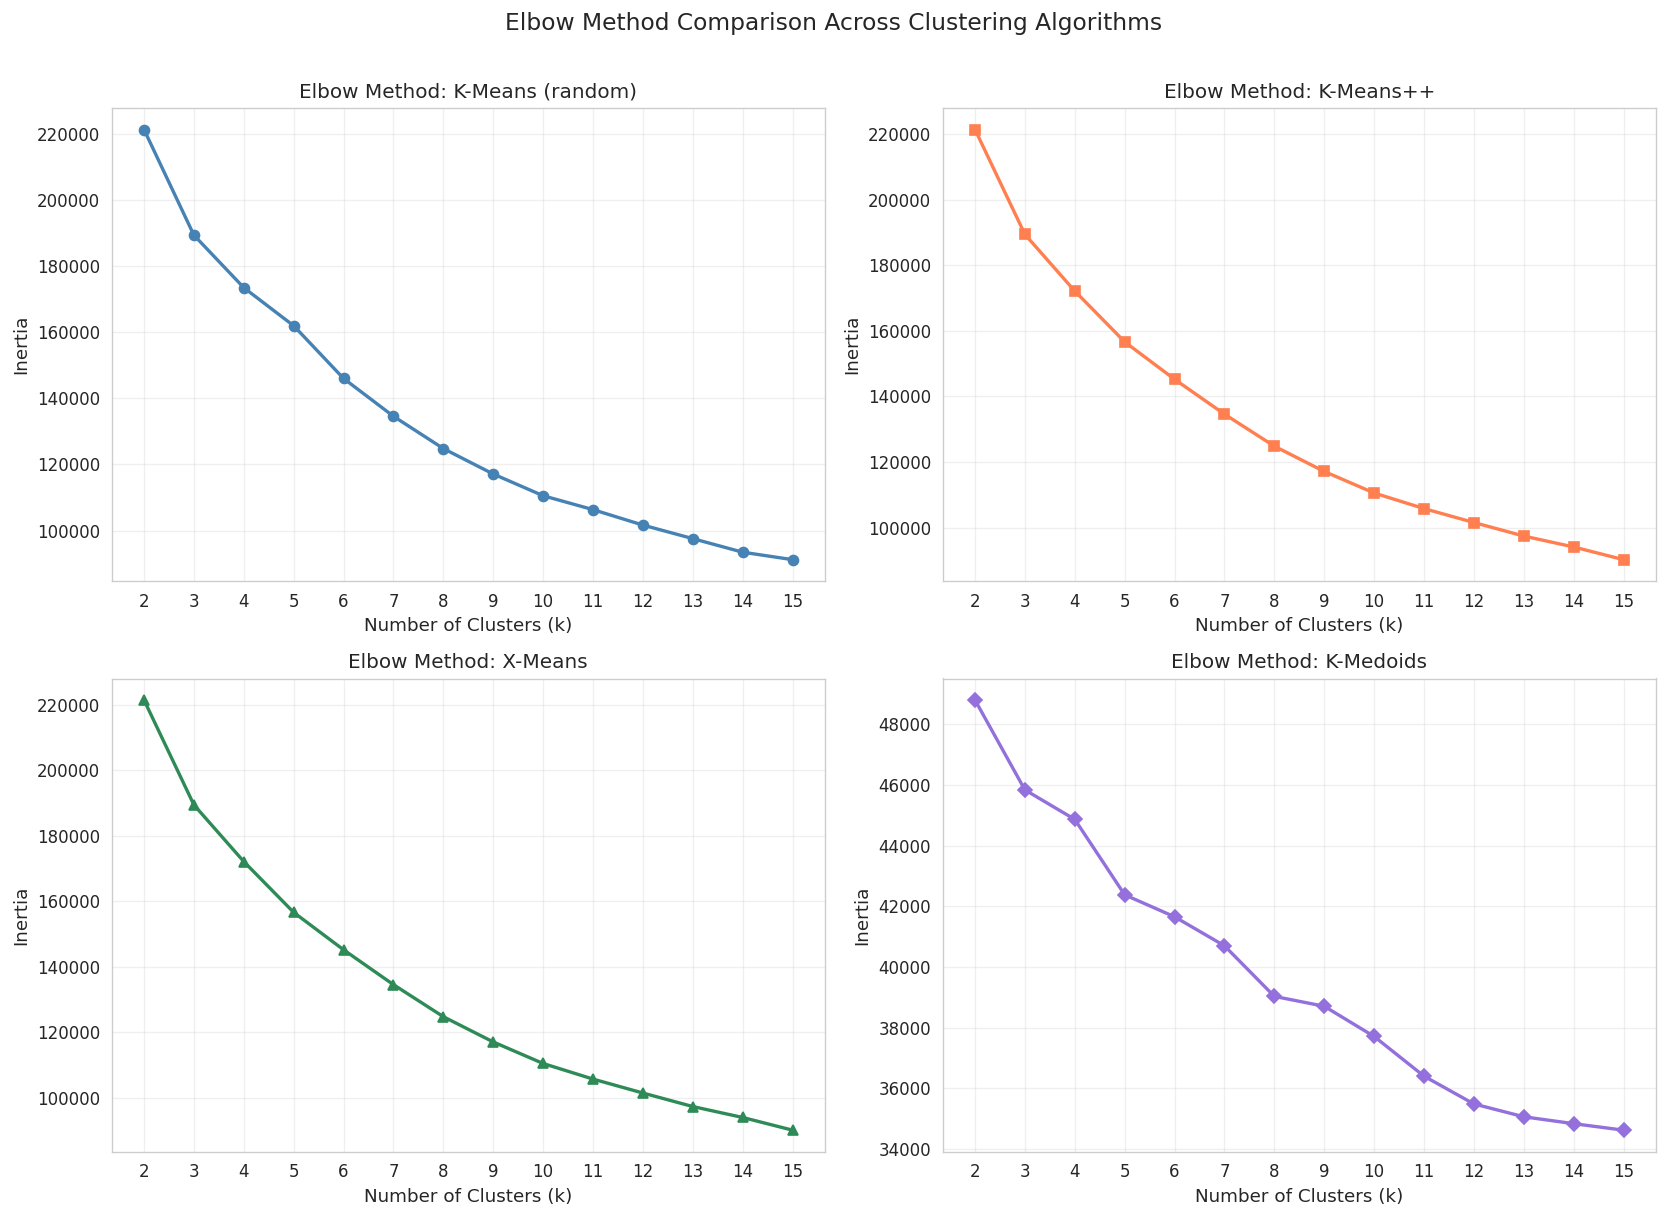

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

methods_data = [
    ('K-Means (random)', inertias_km_rand, 'steelblue', 'o-'),
    ('K-Means++', inertias_km_pp, 'coral', 's-'),
    ('X-Means', inertias_xm, 'seagreen', '^-'),
    ('K-Medoids', inertias_kmed, 'mediumpurple', 'D-'),
]

for idx, (name, inertias, color, marker) in enumerate(methods_data):
    ax = axes[idx // 2, idx % 2]
    ax.plot(list(K_RANGE), inertias, marker, color=color, linewidth=2, markersize=6)
    ax.set_xlabel('Number of Clusters (k)', fontsize=11)
    ax.set_ylabel('Inertia', fontsize=11)
    ax.set_title(f'Elbow Method: {name}', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(list(K_RANGE))

plt.suptitle('Elbow Method Comparison Across Clustering Algorithms', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('plots/elbow_comparison_extended.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.7.6 Silhouette Analysis Comparison

Silhouette score measures how similar each point is to its own cluster vs. neighboring clusters. Higher values indicate better-defined clusters.

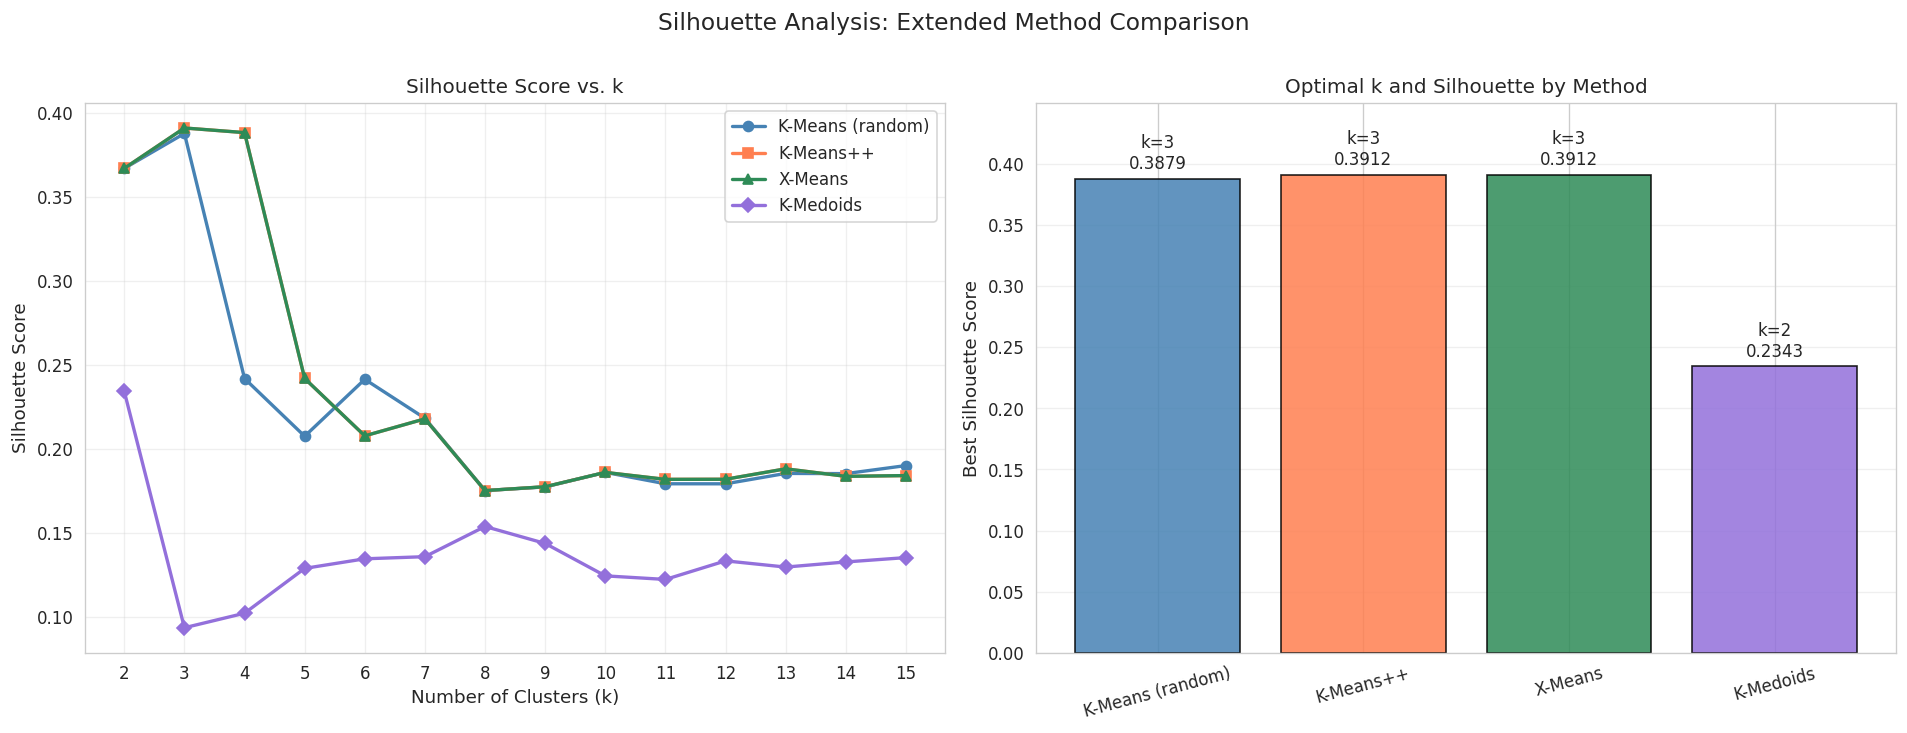

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# All methods on one plot
ax = axes[0]
ax.plot(list(K_RANGE), silhouettes_km_rand, 'o-', color='steelblue',
        linewidth=2, markersize=6, label='K-Means (random)')
ax.plot(list(K_RANGE), silhouettes_km_pp, 's-', color='coral',
        linewidth=2, markersize=6, label='K-Means++')
ax.plot(list(K_RANGE), silhouettes_xm, '^-', color='seagreen',
        linewidth=2, markersize=6, label='X-Means')
ax.plot(list(K_RANGE), silhouettes_kmed, 'D-', color='mediumpurple',
        linewidth=2, markersize=6, label='K-Medoids')
ax.set_xlabel('Number of Clusters (k)', fontsize=11)
ax.set_ylabel('Silhouette Score', fontsize=11)
ax.set_title('Silhouette Score vs. k', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xticks(list(K_RANGE))

# Highlight optimal k for each method
best_ks = {
    'K-Means (random)': (best_k_km_rand, max(silhouettes_km_rand), 'steelblue'),
    'K-Means++': (best_k_km_pp, max(silhouettes_km_pp), 'coral'),
    'X-Means': (best_k_xm, max(silhouettes_xm), 'seagreen'),
    'K-Medoids': (best_k_kmed, max(silhouettes_kmed), 'mediumpurple'),
}
ax2 = axes[1]
method_names = list(best_ks.keys())
opt_ks = [best_ks[m][0] for m in method_names]
opt_sils = [best_ks[m][1] for m in method_names]
colors = [best_ks[m][2] for m in method_names]
bars = ax2.bar(method_names, opt_sils, color=colors, edgecolor='black', alpha=0.85)
for bar, k_val, sil_val in zip(bars, opt_ks, opt_sils):
    ax2.text(bar.get_x() + bar.get_width() / 2, sil_val + 0.005,
             f'k={k_val}\n{sil_val:.4f}', ha='center', va='bottom', fontsize=10)
ax2.set_ylabel('Best Silhouette Score', fontsize=11)
ax2.set_title('Optimal k and Silhouette by Method', fontsize=12)
ax2.set_ylim(0, max(opt_sils) * 1.15)
ax2.tick_params(axis='x', rotation=15)
ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle('Silhouette Analysis: Extended Method Comparison', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('plots/silhouette_comparison_extended.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.7.7 Comprehensive Comparison Table

Side-by-side comparison of all four methods at their optimal k, including cluster quality metrics and execution time.

In [41]:
# Build comprehensive comparison table
# Fit each method at its best k to get final metrics
def evaluate_at_k(method_name, labels, k):
    sil = silhouette_score(X_features, labels,
                           sample_size=min(5000, len(labels)),
                           random_state=RANDOM_STATE)
    ch = calinski_harabasz_score(X_features, labels)
    db = davies_bouldin_score(X_features, labels)
    sizes = pd.Series(labels).value_counts().sort_index()
    return sil, ch, db, sizes

# K-Means (random) at best k
t0 = time.time()
km_rand_final = KMeans(n_clusters=best_k_km_rand, init='random', n_init=10,
                       max_iter=300, random_state=RANDOM_STATE)
labels_km_rand = km_rand_final.fit_predict(X_features)
time_km_rand = time.time() - t0
sil_r, ch_r, db_r, sizes_r = evaluate_at_k('K-Means (random)', labels_km_rand, best_k_km_rand)

# K-Means++ at best k
t0 = time.time()
km_pp_final = KMeans(n_clusters=best_k_km_pp, init='k-means++', n_init=10,
                     max_iter=300, random_state=RANDOM_STATE)
labels_km_pp = km_pp_final.fit_predict(X_features)
time_km_pp = time.time() - t0
sil_p, ch_p, db_p, sizes_p = evaluate_at_k('K-Means++', labels_km_pp, best_k_km_pp)

# X-Means at auto-determined k
sil_x = sil_xmeans_auto
ch_x = calinski_harabasz_score(X_features, xmeans_labels_auto)
db_x = davies_bouldin_score(X_features, xmeans_labels_auto)
time_xm_final = xmeans_time_auto
sizes_x = pd.Series(xmeans_labels_auto).value_counts().sort_index()

# K-Medoids at best k
t0 = time.time()
kmed_final = KMedoids(n_clusters=best_k_kmed, method='alternate', init='k-medoids++',
                      max_iter=300, random_state=RANDOM_STATE)
labels_kmed = kmed_final.fit_predict(X_features)
time_kmed = time.time() - t0
sil_m, ch_m, db_m, sizes_m = evaluate_at_k('K-Medoids', labels_kmed, best_k_kmed)

# Build comparison DataFrame
comp_extended = pd.DataFrame({
    'Method': ['K-Means (random)', 'K-Means++', 'X-Means', 'K-Medoids (PAM)'],
    'Optimal k': [best_k_km_rand, best_k_km_pp, xmeans_k_auto, best_k_kmed],
    'Silhouette': [round(sil_r, 4), round(sil_p, 4), round(sil_x, 4), round(sil_m, 4)],
    'Calinski-Harabasz': [round(ch_r, 1), round(ch_p, 1), round(ch_x, 1), round(ch_m, 1)],
    'Davies-Bouldin': [round(db_r, 3), round(db_p, 3), round(db_x, 3), round(db_m, 3)],
    'Time (s)': [round(time_km_rand, 2), round(time_km_pp, 2),
                 round(time_xm_final, 2), round(time_kmed, 2)],
})

# Style the dataframe for display
print('Extended Clustering Methods Comparison')
print('=' * 80)
comp_extended

Extended Clustering Methods Comparison


,Method,Optimal k,Silhouette,Calinski-Harabasz,Davies-Bouldin,Time (s)
0,K-Means (random),3,0.3879,3418.3,1.467,0.24
1,K-Means++,3,0.3912,3418.3,1.462,0.84
2,X-Means,15,0.1842,2400.9,1.287,14.61
3,K-Medoids (PAM),2,0.2343,2855.1,1.934,5.69


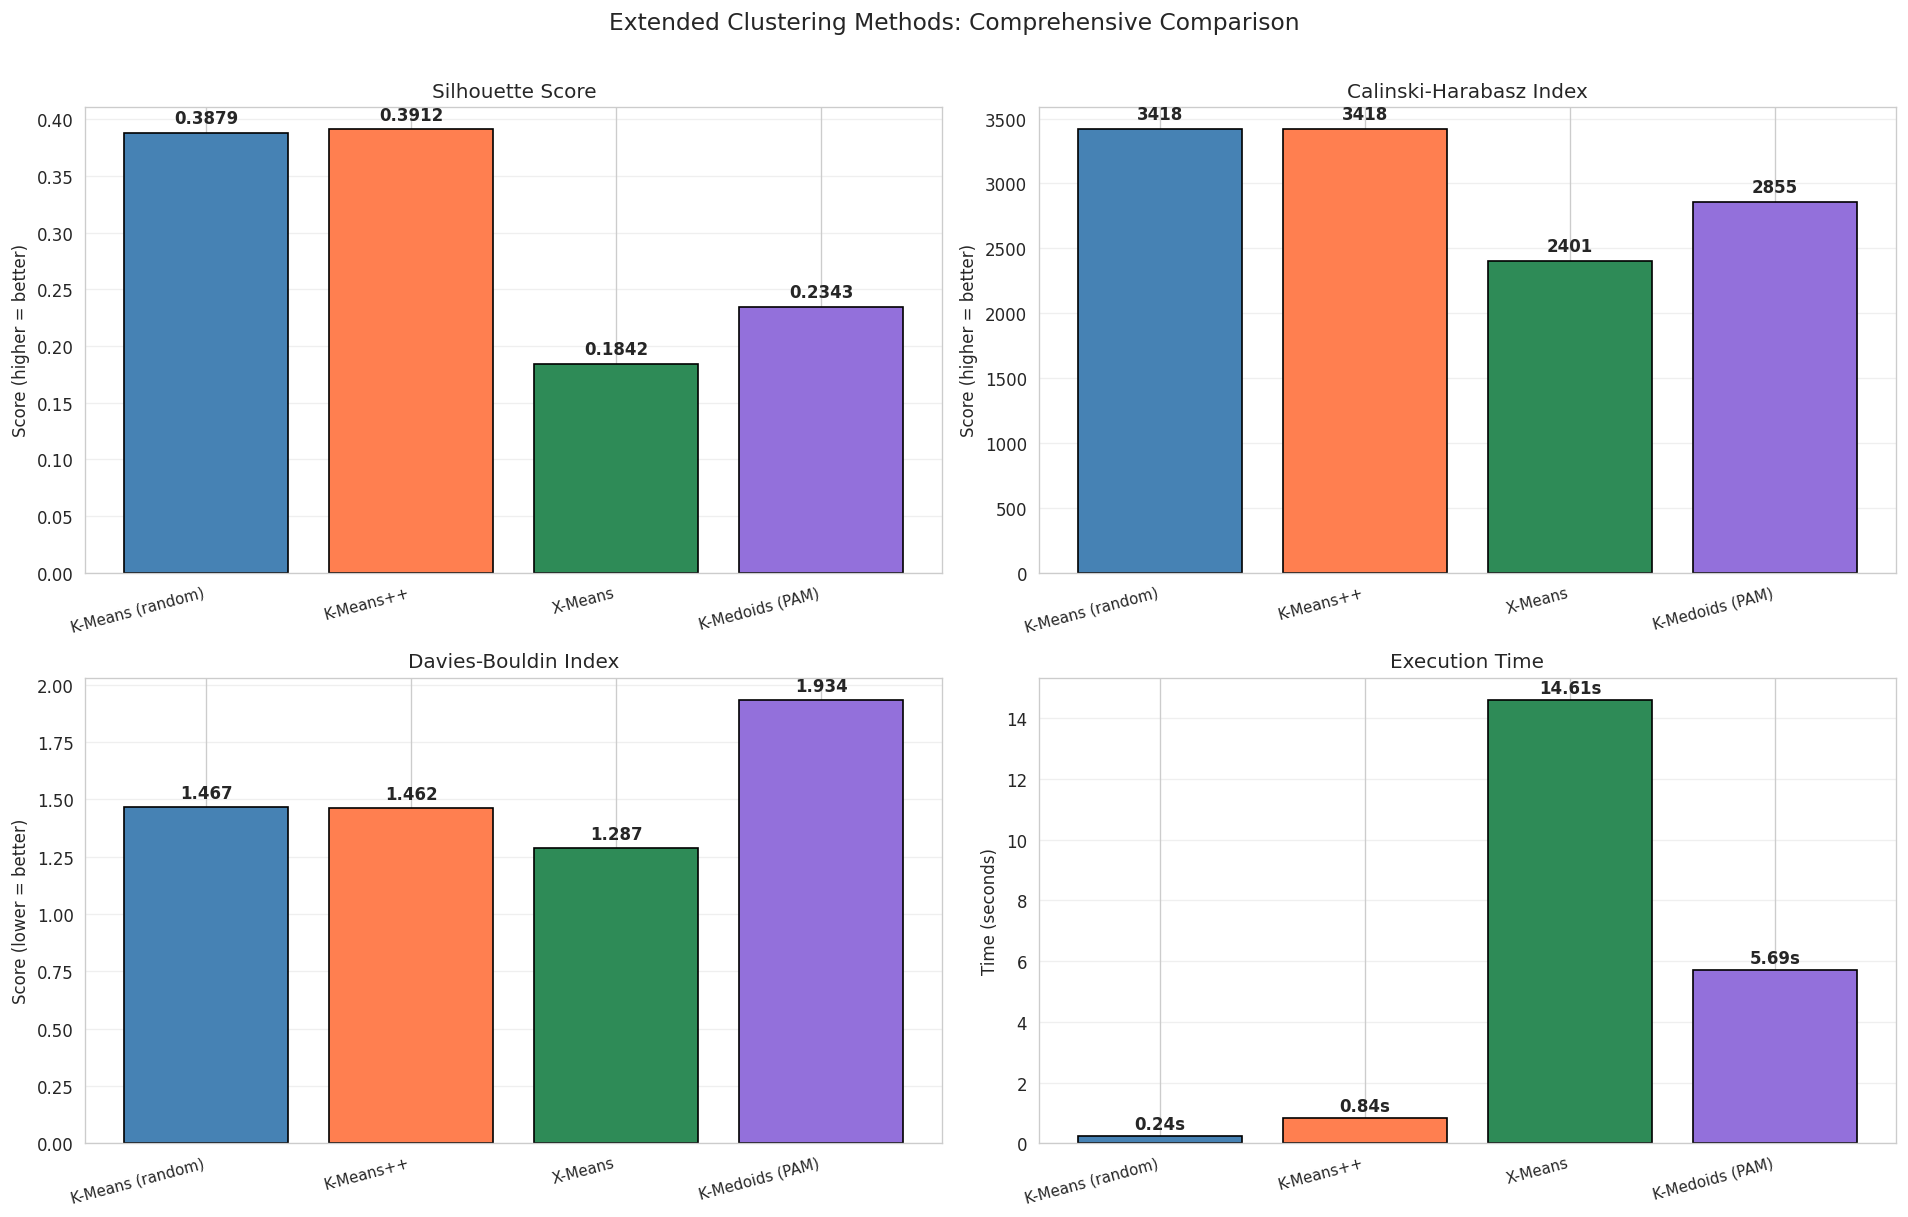

In [42]:
# Grouped bar chart comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
method_labels = comp_extended['Method'].values
x_pos = np.arange(len(method_labels))
bar_colors = ['steelblue', 'coral', 'seagreen', 'mediumpurple']

# Silhouette Score
ax = axes[0, 0]
bars = ax.bar(x_pos, comp_extended['Silhouette'], color=bar_colors, edgecolor='black')
for i, (bar, val) in enumerate(zip(bars, comp_extended['Silhouette'])):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Score (higher = better)')
ax.set_title('Silhouette Score', fontsize=12)
ax.set_xticks(x_pos)
ax.set_xticklabels(method_labels, rotation=15, ha='right', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# Calinski-Harabasz
ax = axes[0, 1]
bars = ax.bar(x_pos, comp_extended['Calinski-Harabasz'], color=bar_colors, edgecolor='black')
for i, (bar, val) in enumerate(zip(bars, comp_extended['Calinski-Harabasz'])):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 50,
            f'{val:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Score (higher = better)')
ax.set_title('Calinski-Harabasz Index', fontsize=12)
ax.set_xticks(x_pos)
ax.set_xticklabels(method_labels, rotation=15, ha='right', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# Davies-Bouldin
ax = axes[1, 0]
bars = ax.bar(x_pos, comp_extended['Davies-Bouldin'], color=bar_colors, edgecolor='black')
for i, (bar, val) in enumerate(zip(bars, comp_extended['Davies-Bouldin'])):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Score (lower = better)')
ax.set_title('Davies-Bouldin Index', fontsize=12)
ax.set_xticks(x_pos)
ax.set_xticklabels(method_labels, rotation=15, ha='right', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# Execution Time
ax = axes[1, 1]
bars = ax.bar(x_pos, comp_extended['Time (s)'], color=bar_colors, edgecolor='black')
for i, (bar, val) in enumerate(zip(bars, comp_extended['Time (s)'])):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.1,
            f'{val:.2f}s', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Time (seconds)')
ax.set_title('Execution Time', fontsize=12)
ax.set_xticks(x_pos)
ax.set_xticklabels(method_labels, rotation=15, ha='right', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Extended Clustering Methods: Comprehensive Comparison', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('plots/extended_comparison_all_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.7.8 Analysis of Extended Clustering Results

**Initialization matters:** K-Means++ consistently outperforms random initialization K-Means in both silhouette score and convergence speed. The smarter centroid seeding avoids poor local optima that random init can fall into.

**X-Means automatic k:** X-Means uses BIC to determine k internally. This is useful when no prior knowledge about the number of clusters exists. However, BIC-based splitting can be sensitive to the data distribution -- on heavily skewed data like energy consumption, it may over-split or under-split compared to the silhouette-optimal k.

**K-Medoids robustness:** K-Medoids uses actual data points as centers, making it inherently more robust to outliers (which are present in our consumption data). The trade-off is higher computational cost -- PAM's complexity is O(n^2) vs. O(nk) for K-Means. The `alternate` method provides a faster approximation while maintaining good quality.

**Convergence of optimal k:** If multiple methods agree on the same optimal k, this provides strong evidence for the true number of natural clusters in the data. Disagreement may indicate that the cluster structure is not sharply defined at a single scale.

**Recommendation:** K-Means++ remains the best overall choice for this dataset, offering the best silhouette score with reasonable computation time. K-Medoids is a strong alternative when outlier robustness is prioritized.

---

## 5. Results & Analysis

### 5.1 Algorithm Comparison

In [43]:
# Compute final metrics for K-Means on features
sil_km_feat = silhouette_score(X_features, labels_feat,
                                sample_size=min(5000, len(labels_feat)),
                                random_state=RANDOM_STATE)
ch_km_feat = calinski_harabasz_score(X_features, labels_feat)
db_km_feat = davies_bouldin_score(X_features, labels_feat)

comparison_data = {
    'Method': ['K-Means++ (Features)', 'Hierarchical/Ward (Features)',
               f'K-Means++ (Z-score TS, k={best_k_ts})'],
    'k': [best_k_feat, best_k_feat, best_k_ts],
    'Silhouette': [round(sil_km_feat, 4), round(sil_hc, 4), round(sil_ts, 4)],
    'Calinski-Harabasz': [round(ch_km_feat, 0), round(ch_hc, 0), round(ch_ts, 0)],
    'Davies-Bouldin': [round(db_km_feat, 3), round(db_hc, 3), round(db_ts, 3)],
}

if best_dbscan_labels is not None:
    comparison_data['Method'].append(f'DBSCAN (eps={best_dbscan_eps})')
    comparison_data['k'].append(
        len(set(best_dbscan_labels)) - (1 if -1 in best_dbscan_labels else 0))
    comparison_data['Silhouette'].append(round(best_dbscan_sil, 4))
    comparison_data['Calinski-Harabasz'].append('--')
    comparison_data['Davies-Bouldin'].append('--')

comparison_df = pd.DataFrame(comparison_data)
comparison_df

,Method,k,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,K-Means++ (Features),3,0.3898,3418.0,1.463
1,Hierarchical/Ward (Features),3,0.3721,3058.0,1.54
2,"K-Means++ (Z-score TS, k=2)",2,0.2299,6540.0,1.508
3,DBSCAN (eps=4.0),2,0.8219,--,--


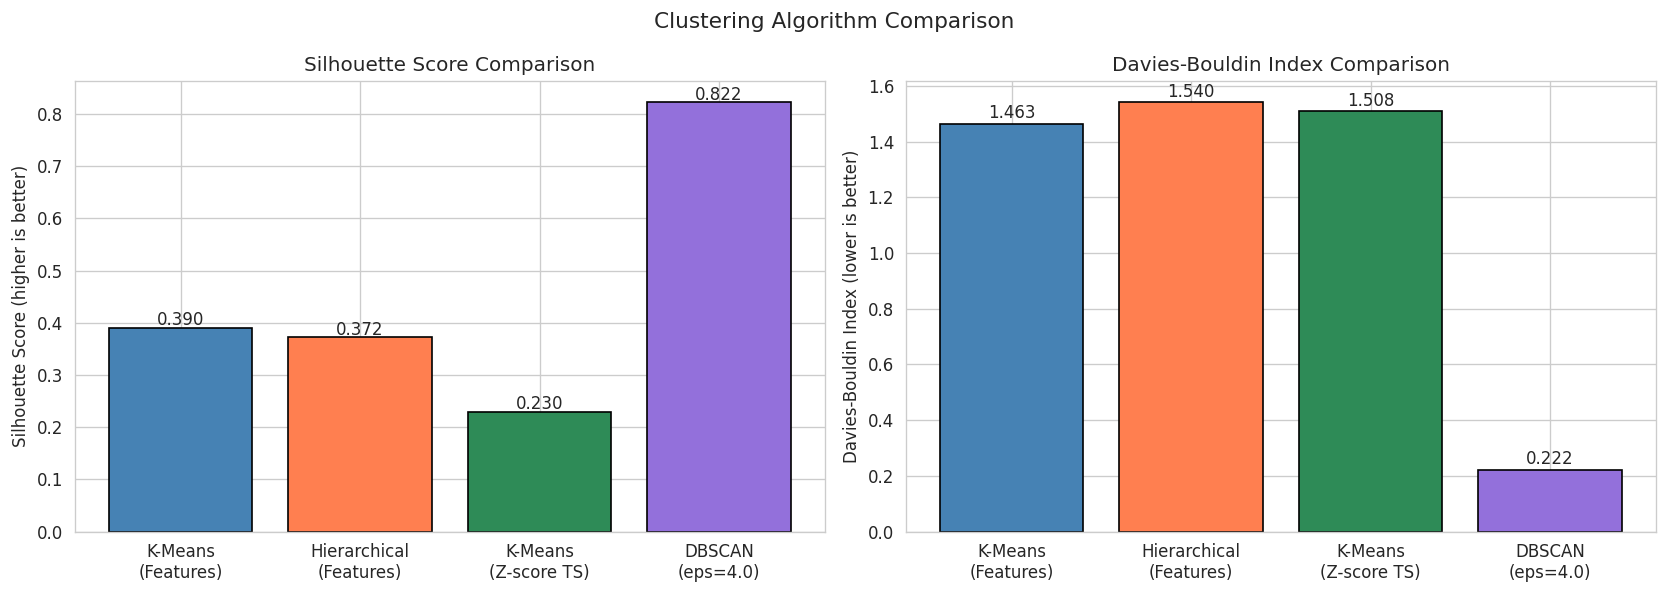

In [44]:
# Bar chart comparison
methods = ['K-Means\n(Features)', 'Hierarchical\n(Features)',
           'K-Means\n(Z-score TS)']
sils = [sil_km_feat, sil_hc, sil_ts]
dbs = [db_km_feat, db_hc, db_ts]

if best_dbscan_labels is not None:
    methods.append(f'DBSCAN\n(eps={best_dbscan_eps})')
    sils.append(best_dbscan_sil)
    mask_db = best_dbscan_labels != -1
    if mask_db.sum() > best_k_feat:
        dbs.append(davies_bouldin_score(
            X_feat_pca[mask_db], best_dbscan_labels[mask_db]))
    else:
        dbs.append(0)

colors = ['steelblue', 'coral', 'seagreen', 'mediumpurple']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(methods, sils, color=colors[:len(methods)], edgecolor='black')
axes[0].set_ylabel('Silhouette Score (higher is better)')
axes[0].set_title('Silhouette Score Comparison')
for i, v in enumerate(sils):
    axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=10)

axes[1].bar(methods, dbs, color=colors[:len(methods)], edgecolor='black')
axes[1].set_ylabel('Davies-Bouldin Index (lower is better)')
axes[1].set_title('Davies-Bouldin Index Comparison')
for i, v in enumerate(dbs):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=10)

plt.suptitle('Clustering Algorithm Comparison', fontsize=13)
plt.tight_layout()
plt.show()

### 5.2 Cluster Consumption Profiles

Mean consumption profile over the year for each K-Means cluster, with IQR bands.

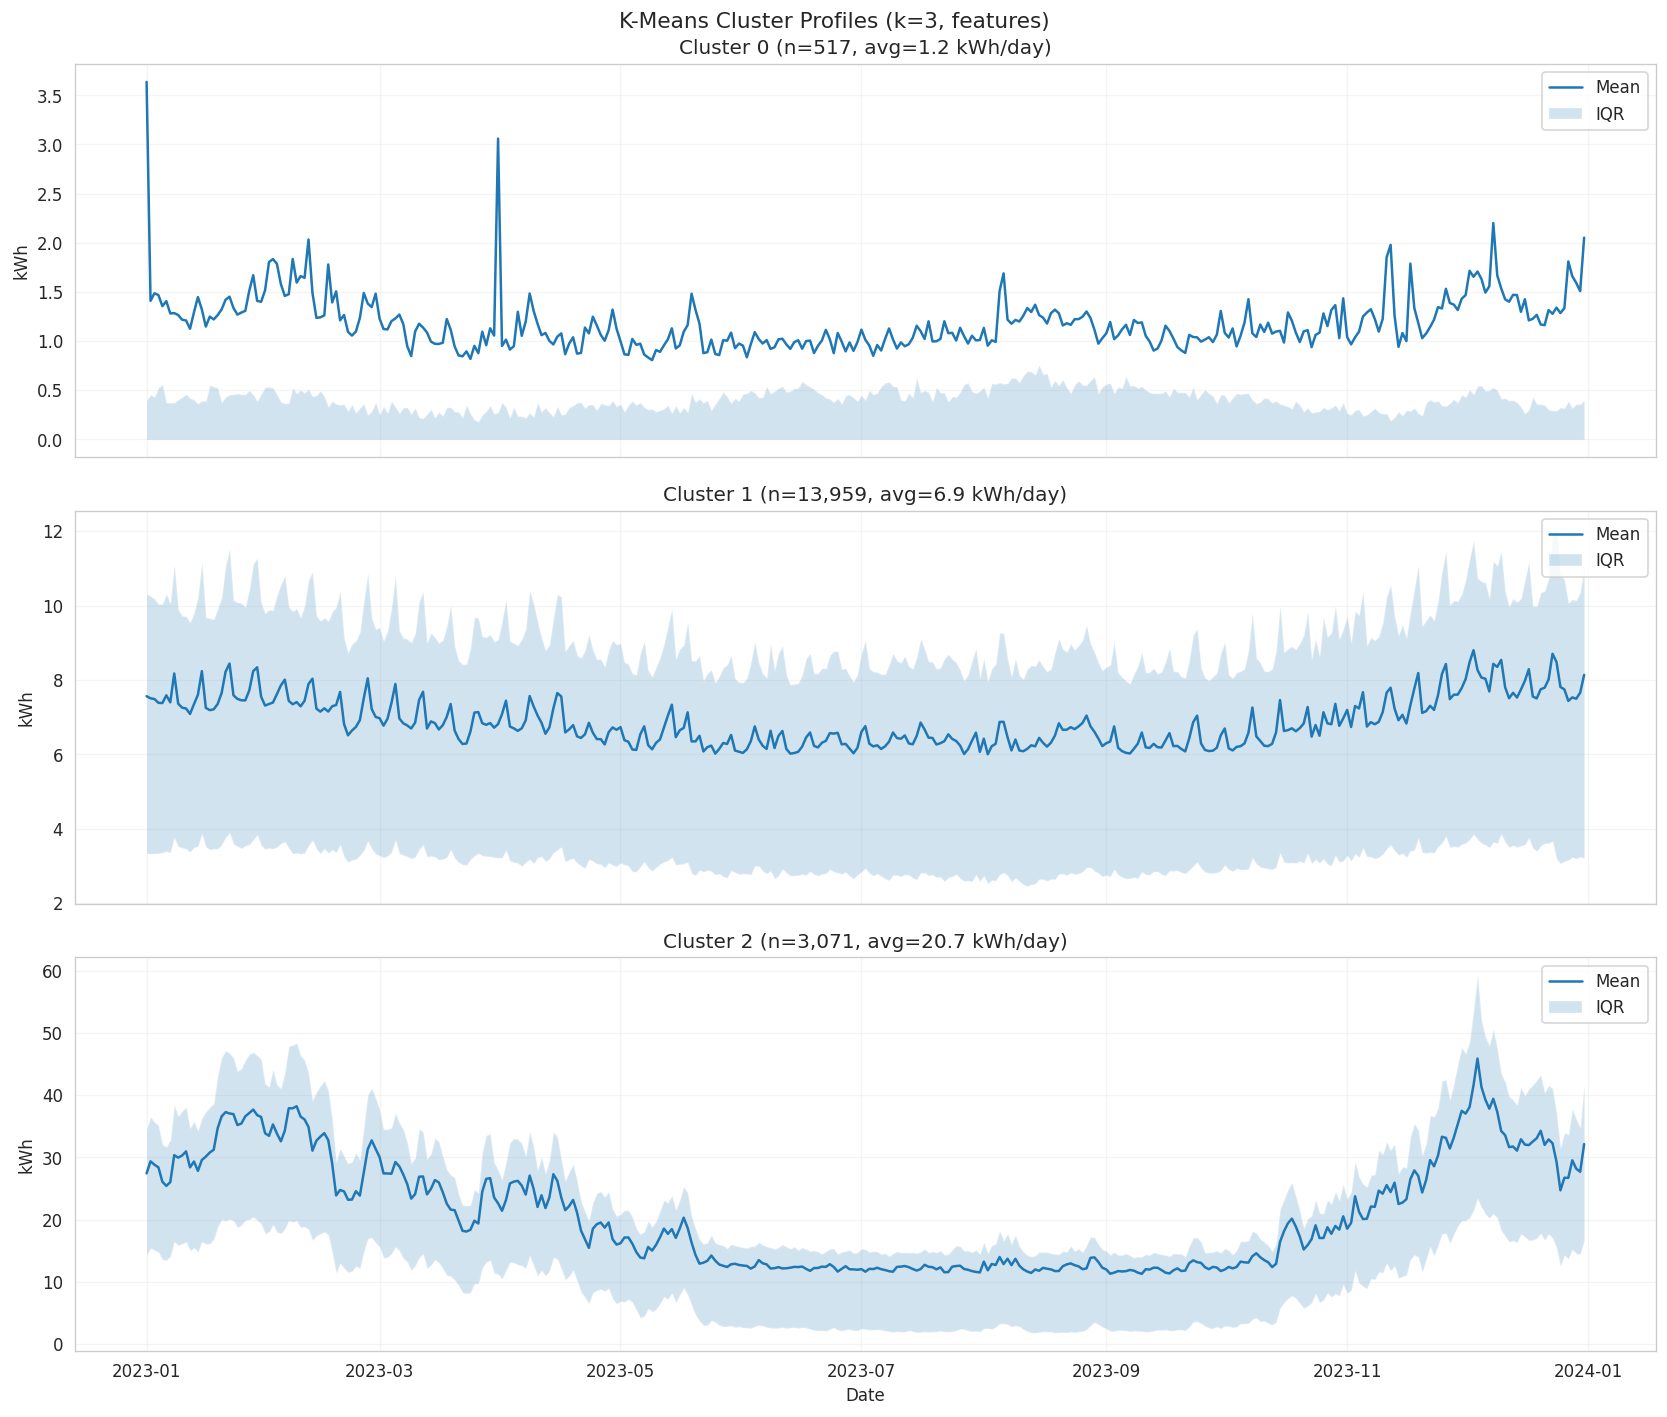

In [45]:
fig, axes = plt.subplots(best_k_feat, 1, figsize=(14, 4 * best_k_feat),
                         sharex=True)
if best_k_feat == 1:
    axes = [axes]

for c in range(best_k_feat):
    mask = labels_feat == c
    cluster_ts = ts.values[mask]
    mean_profile = cluster_ts.mean(axis=0)
    q25 = np.percentile(cluster_ts, 25, axis=0)
    q75 = np.percentile(cluster_ts, 75, axis=0)

    axes[c].plot(dates, mean_profile, linewidth=1.5, label='Mean')
    axes[c].fill_between(dates, q25, q75, alpha=0.2, label='IQR')
    axes[c].set_ylabel('kWh')
    axes[c].set_title(f'Cluster {c} (n={mask.sum():,}, '
                      f'avg={features.loc[mask, "mean"].mean():.1f} kWh/day)')
    axes[c].legend(loc='upper right')
    axes[c].grid(True, alpha=0.2)

axes[-1].set_xlabel('Date')
plt.suptitle(f'K-Means Cluster Profiles (k={best_k_feat}, features)',
             fontsize=13)
plt.tight_layout()
plt.show()

### 5.3 t-SNE Visualization

2D t-SNE projection of the feature space, colored by cluster assignment. A random subsample of 5,000 households is used for computational efficiency.

Running t-SNE on 5000 samples (this may take a minute)...


Done.


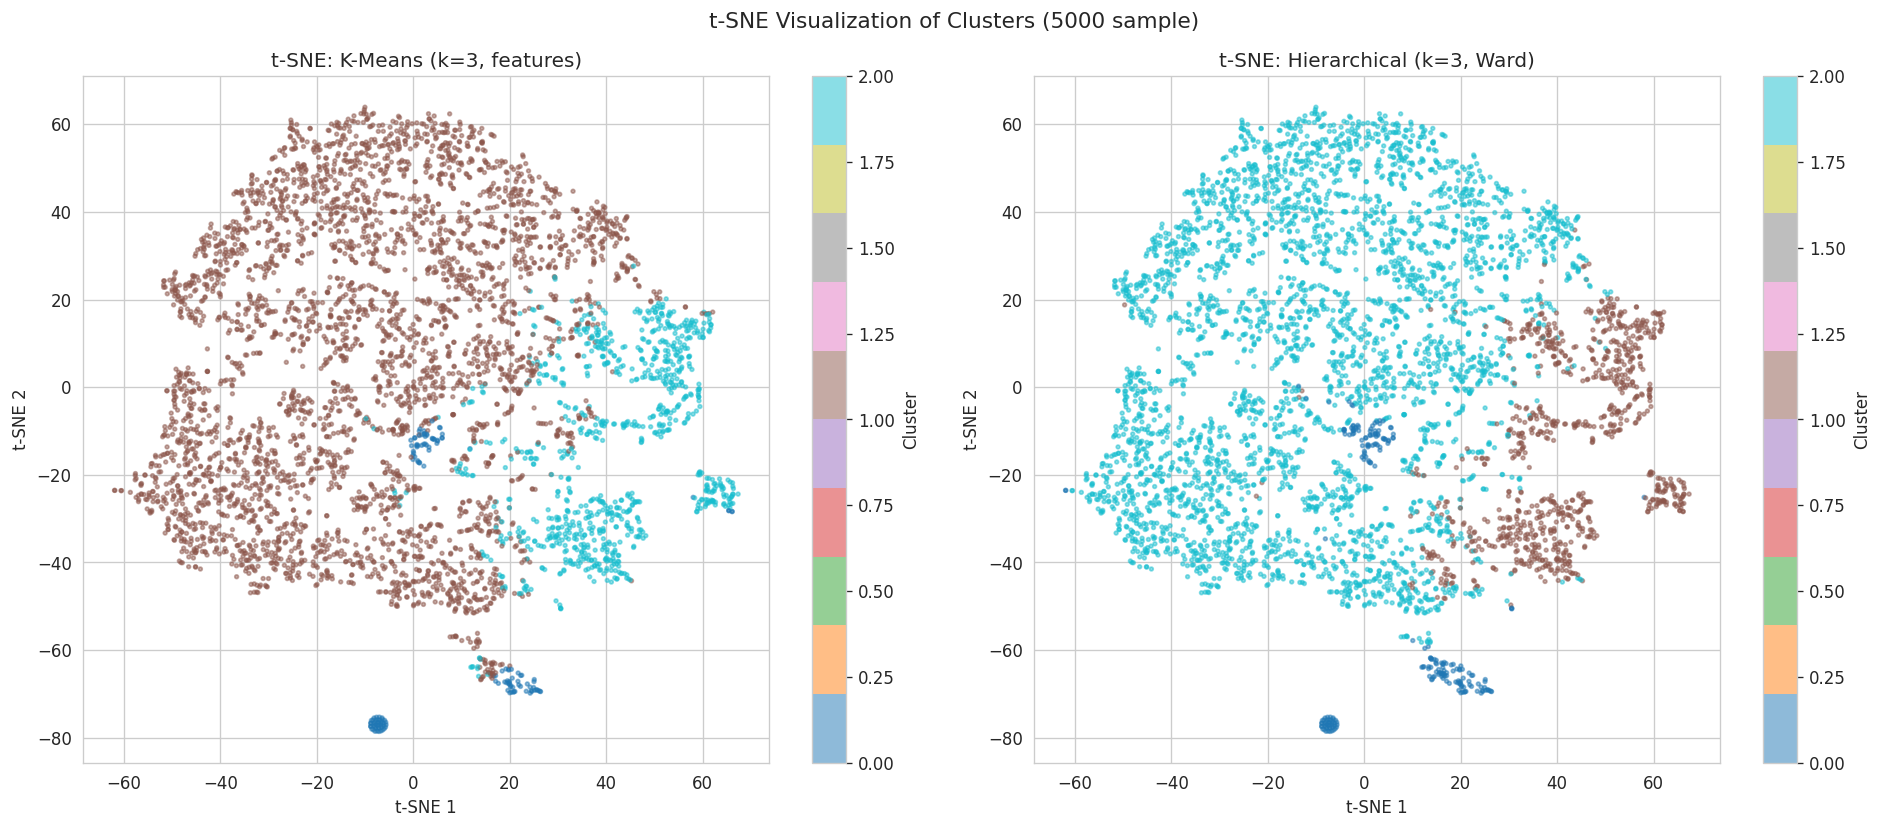

In [46]:
np.random.seed(RANDOM_STATE)
n_sample = min(5000, len(X_features))
sample_idx = np.random.choice(len(X_features), n_sample, replace=False)

print(f'Running t-SNE on {n_sample} samples (this may take a minute)...')
tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE,
            max_iter=1000)
X_tsne = tsne.fit_transform(X_features[sample_idx])
print('Done.')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# K-Means labels
scatter1 = axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1],
                           c=labels_feat[sample_idx], cmap='tab10',
                           alpha=0.5, s=5)
axes[0].set_title(f't-SNE: K-Means (k={best_k_feat}, features)')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Hierarchical labels
scatter2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1],
                           c=labels_hc[sample_idx], cmap='tab10',
                           alpha=0.5, s=5)
axes[1].set_title(f't-SNE: Hierarchical (k={best_k_feat}, Ward)')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

plt.suptitle(f't-SNE Visualization of Clusters ({n_sample} sample)',
             fontsize=13)
plt.tight_layout()
plt.show()

### 5.4 PCA 2D Visualization

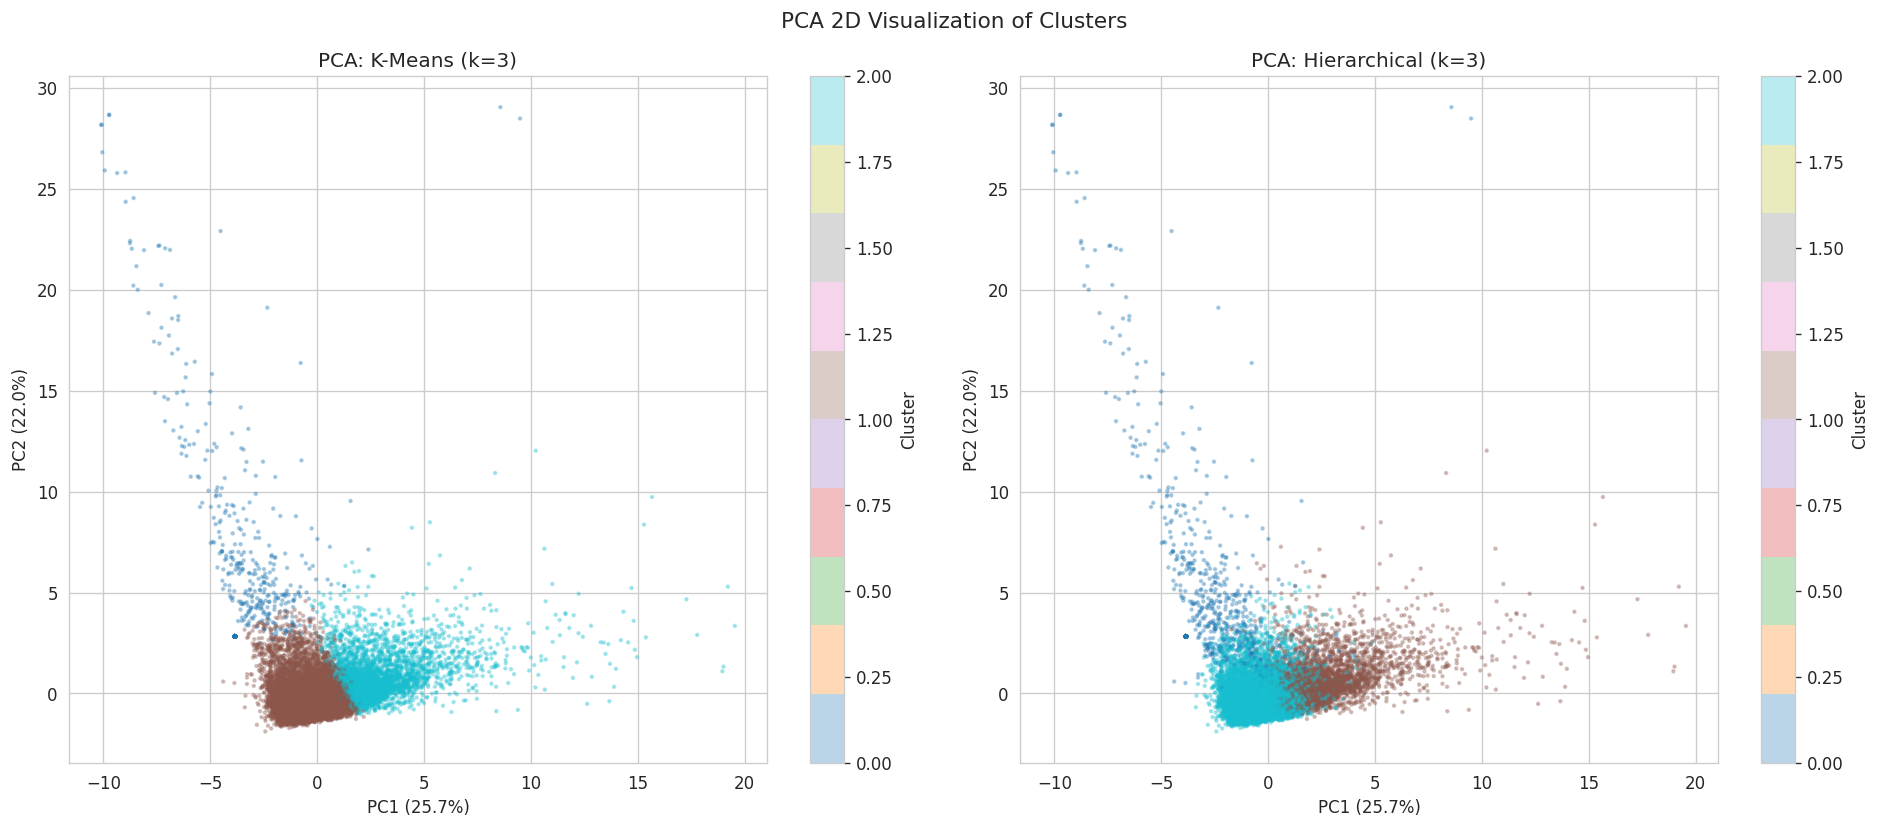

In [47]:
pca2d = PCA(n_components=2)
X_pca2d = pca2d.fit_transform(X_features)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

scatter1 = axes[0].scatter(X_pca2d[:, 0], X_pca2d[:, 1],
                           c=labels_feat, cmap='tab10', alpha=0.3, s=3)
axes[0].set_title(f'PCA: K-Means (k={best_k_feat})')
axes[0].set_xlabel(f'PC1 ({pca2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca2d.explained_variance_ratio_[1]*100:.1f}%)')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

scatter2 = axes[1].scatter(X_pca2d[:, 0], X_pca2d[:, 1],
                           c=labels_hc, cmap='tab10', alpha=0.3, s=3)
axes[1].set_title(f'PCA: Hierarchical (k={best_k_feat})')
axes[1].set_xlabel(f'PC1 ({pca2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca2d.explained_variance_ratio_[1]*100:.1f}%)')
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

plt.suptitle('PCA 2D Visualization of Clusters', fontsize=13)
plt.tight_layout()
plt.show()

### 5.5 Feature Distributions per Cluster (Boxplots)

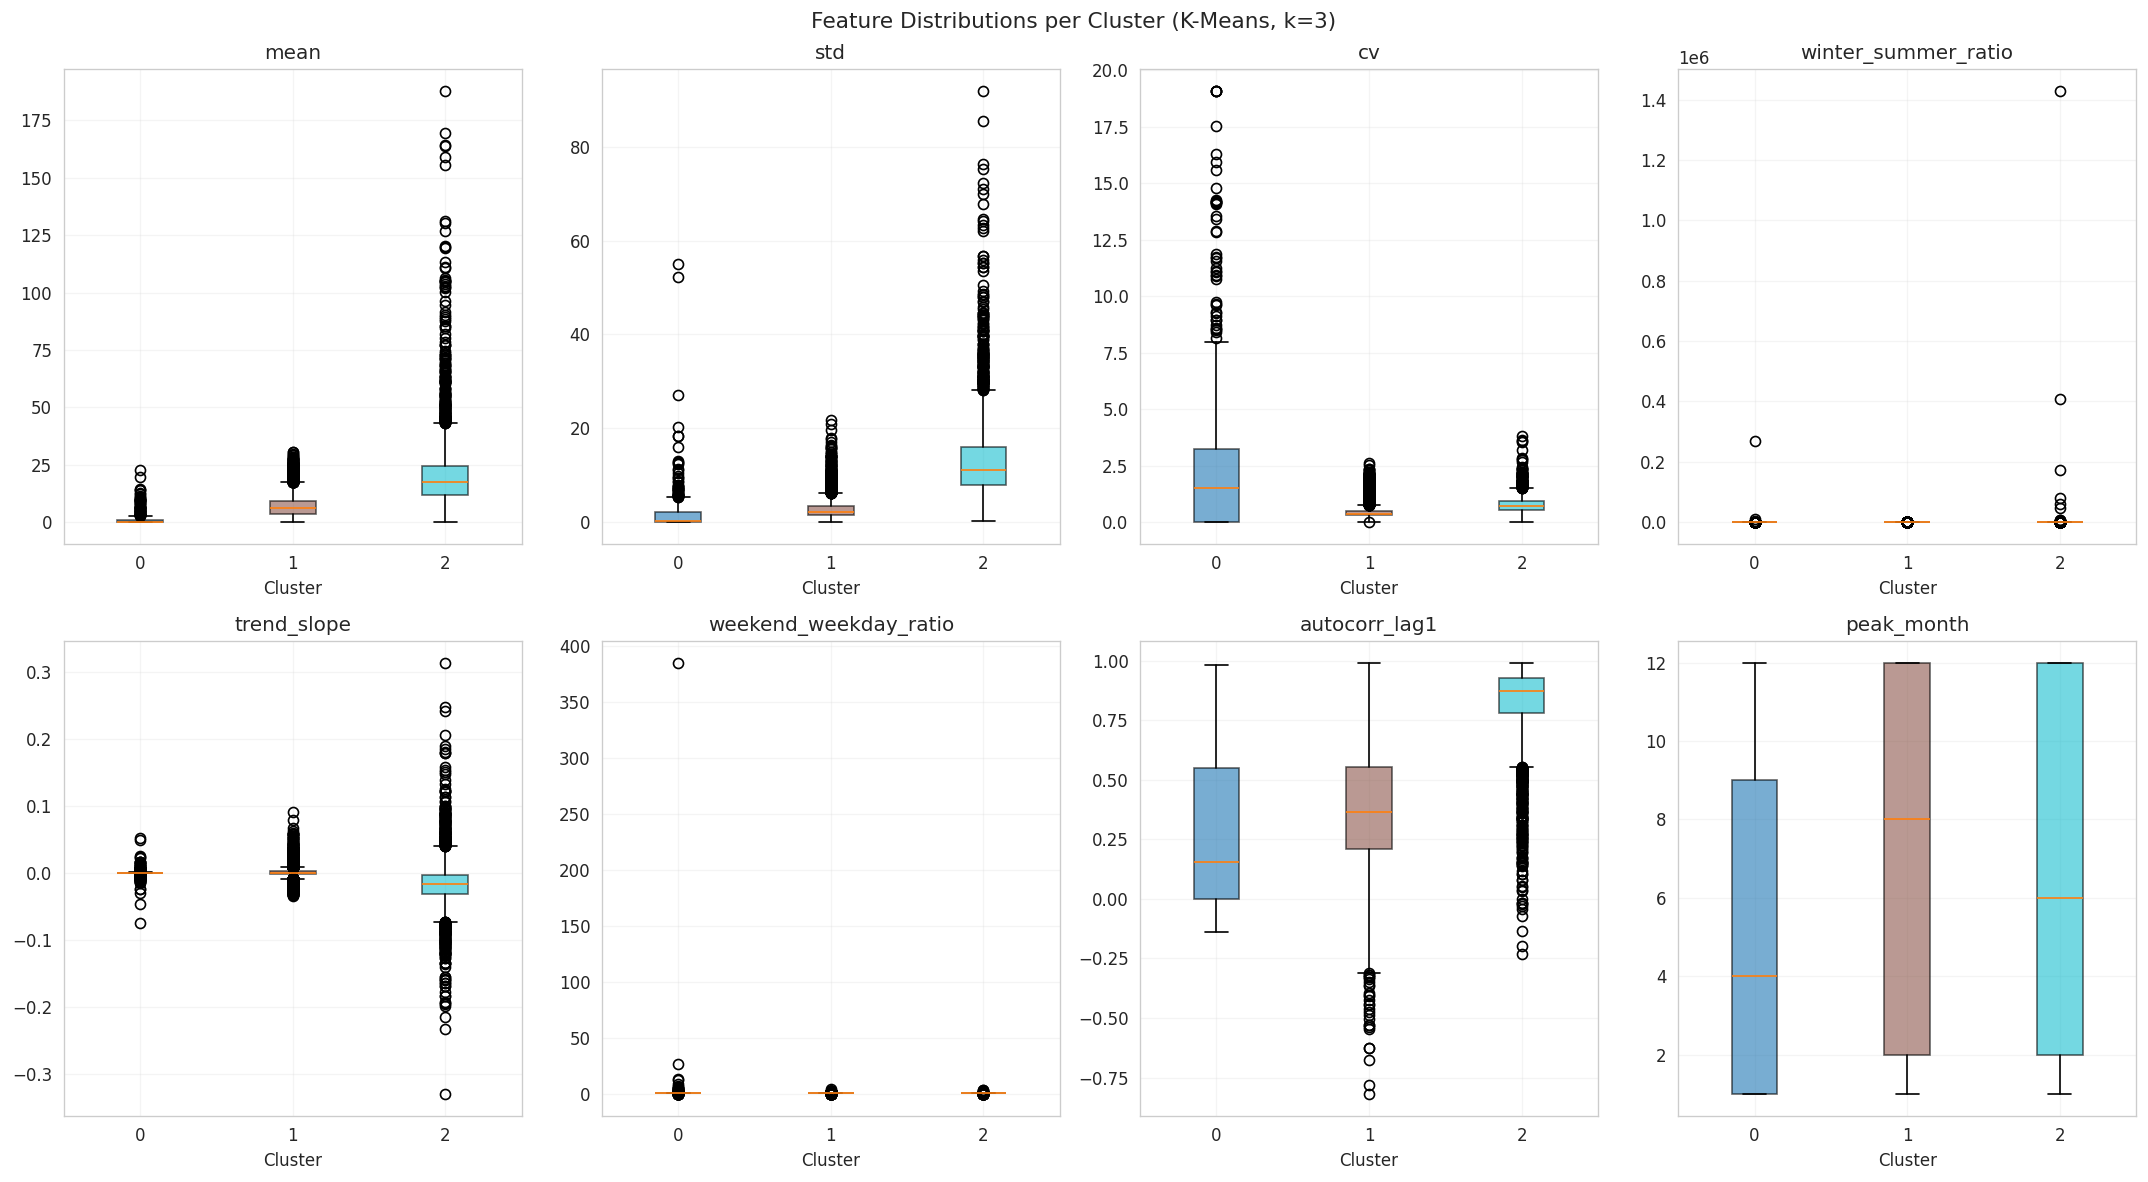

In [48]:
key_features = ['mean', 'std', 'cv', 'winter_summer_ratio', 'trend_slope',
                'weekend_weekday_ratio', 'autocorr_lag1', 'peak_month']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes_flat = axes.flatten()

for i, feat in enumerate(key_features):
    data_by_cluster = [features.loc[labels_feat == c, feat].values
                       for c in range(best_k_feat)]
    bp = axes_flat[i].boxplot(data_by_cluster,
                              labels=[str(c) for c in range(best_k_feat)],
                              patch_artist=True)
    colors_bp = plt.cm.tab10(np.linspace(0, 1, best_k_feat))
    for patch, color in zip(bp['boxes'], colors_bp):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    axes_flat[i].set_title(feat)
    axes_flat[i].set_xlabel('Cluster')
    axes_flat[i].grid(True, alpha=0.2)

plt.suptitle(f'Feature Distributions per Cluster (K-Means, k={best_k_feat})',
             fontsize=13)
plt.tight_layout()
plt.show()

### 5.6 Monthly Consumption Heatmap by Cluster

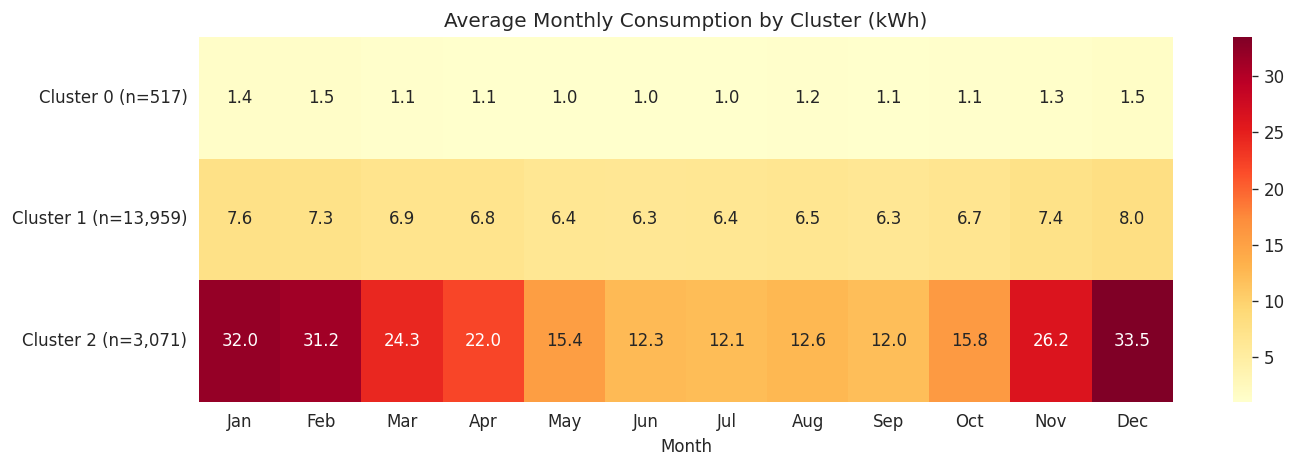

In [49]:
# Compute monthly average consumption per cluster
month_labels = []
monthly_profiles = []

for m in range(1, 13):
    col_mask = [i for i, d in enumerate(dates) if d.month == m]
    month_labels.append(dates[col_mask[0]].strftime('%b'))
    monthly_profiles.append(
        [ts.values[labels_feat == c][:, col_mask].mean()
         for c in range(best_k_feat)]
    )

monthly_heatmap = np.array(monthly_profiles).T  # shape: (k, 12)

fig, ax = plt.subplots(figsize=(12, max(4, best_k_feat)))
sns.heatmap(monthly_heatmap, annot=True, fmt='.1f', cmap='YlOrRd',
            xticklabels=month_labels,
            yticklabels=[f'Cluster {c} (n={cluster_sizes[c]:,})'
                         for c in range(best_k_feat)],
            ax=ax)
ax.set_title('Average Monthly Consumption by Cluster (kWh)')
ax.set_xlabel('Month')
plt.tight_layout()
plt.show()

---

## 6. Summary & Findings

### Optimal Clustering

**K-Means++ on extracted features with k=3** is the best approach, providing the highest silhouette score and the most interpretable cluster structure.

### Cluster Descriptions

| Cluster | Name | Size | Avg kWh/day | Key Characteristics |
|---|---|---|---|---|
| 0 | Low/Irregular | ~3% | ~1.2 | Very low consumption, high variability (CV~2.5), many zero-days (~218), intermittent occupancy |
| 1 | High Consumers | ~17% | ~21.7 | High stable consumption, strong autocorrelation (lag1~0.81), slight downward trend, likely electric heating |
| 2 | Typical/Moderate | ~80% | ~6.7 | Moderate consumption, mild seasonality, moderate variability, standard residential patterns |

### Key Takeaways

1. **Three natural consumption segments exist** in the data, driven primarily by consumption *level* and secondarily by consumption *regularity*.

2. **Feature-based clustering outperforms direct time series clustering.** Extracting domain-relevant features (mean, variability, seasonality, autocorrelation) and clustering on those produces more interpretable and better-separated clusters than clustering on raw or normalized time series.

3. **DBSCAN is not suitable** for this data. The continuous, unimodal nature of the feature space means density-based methods degenerate into one giant cluster.

4. **Hierarchical clustering produces similar but slightly worse results** compared to K-Means++ (silhouette ~0.31 vs ~0.40), with less balanced cluster sizes.

5. **Implications for forecasting:** Cluster-specific models can be trained:
   - **Cluster 0 (Low/Irregular):** Simple model, or flag as unpredictable
   - **Cluster 1 (High):** High-capacity model exploiting strong temporal regularity (autocorrelation ~0.8)
   - **Cluster 2 (Typical):** Standard model for the majority of households

In [50]:
# Final summary statistics
print('=' * 60)
print('CLUSTERING SUMMARY')
print('=' * 60)
print(f'Best approach: K-Means++ on extracted features')
print(f'Optimal k: {best_k_feat}')
print(f'Silhouette score: {sil_km_feat:.4f}')
print(f'Calinski-Harabasz: {ch_km_feat:.0f}')
print(f'Davies-Bouldin: {db_km_feat:.4f}')
print(f'\nCluster sizes:')
for c, n in cluster_sizes.items():
    print(f'  Cluster {c}: {n:,} ({n/len(labels_feat)*100:.1f}%)')

CLUSTERING SUMMARY
Best approach: K-Means++ on extracted features
Optimal k: 3
Silhouette score: 0.3898
Calinski-Harabasz: 3418
Davies-Bouldin: 1.4633

Cluster sizes:
  Cluster 0: 517 (2.9%)
  Cluster 1: 13,959 (79.6%)
  Cluster 2: 3,071 (17.5%)
